# Regresion Lineal con Jupyter Notebook - DATA-DOGS

Notebook alineado con la guia del curso para construir:
- EDA completo
- Regresion lineal simple
- Regresion lineal multiple
- Diagnosticos estadisticos (normalidad, homocedasticidad, multicolinealidad)

Variables del modelo:
- Variable dependiente / objetivo (Y): `vida_promedio`
- Variables independientes (X) - modelo simple: `peso_promedio`
- Variables independientes (X) - modelo multiple: `peso_promedio`, `diferencia_sexual_peso`, `hipo_num`
- Variables objetivo transformadas para diagnostico: `log(vida_promedio)`, `sqrt(vida_promedio)`


In [ ]:
# CELDA 1 - Importaciones y configuracion
# 🎯 Objetivo: importar librerias y configurar estilo para todo el notebook
import os
import sys

sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.outliers_influence import variance_inflation_factor

from scripts.database import engine

os.makedirs('../data/graficas', exist_ok=True)

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

print('OK - Librerias importadas')


In [2]:
# CELDA 2 - Carga de datos desde PostgreSQL
# 🎯 Objetivo: cargar datos desde PostgreSQL en un DataFrame para el analisis
QUERY = """
SELECT
    raza,
    vida_min,
    vida_max,
    vida_promedio,
    peso_macho_max,
    peso_hembra_max,
    peso_promedio,
    categoria_peso,
    diferencia_sexual_peso,
    hipoalergenico,
    fecha_extraccion
FROM razas_perros
ORDER BY fecha_extraccion
"""

df = pd.read_sql(QUERY, engine)

print('OK - Datos cargados')
print(f'Filas    : {df.shape[0]:,}')
print(f'Columnas : {df.shape[1]}')
df.head()


OK - Datos cargados
Filas    : 1,000
Columnas : 11


,raza,vida_min,vida_max,vida_promedio,peso_macho_max,peso_hembra_max,peso_promedio,categoria_peso,diferencia_sexual_peso,hipoalergenico,fecha_extraccion
0,Blue Husky,16,17,16.5,13.8,12.4,13.10,Pequeño,1.4,True,2026-01-14 21:05:12.169405
1,Toy Hunter,14,19,16.5,12.3,11.2,11.75,Pequeño,1.1,False,2026-01-14 21:05:19.148086
2,Brazilian Sheepdog,12,16,14.0,21.6,19.4,20.50,Mediano,2.2,False,2026-01-14 21:05:31.410641
3,Crystal Australian Hunter,14,16,15.0,22.9,19.5,21.20,Mediano,3.4,None,2026-01-14 21:05:33.914629
4,Crystal Shepherd,14,15,14.5,23.0,20.7,21.85,Mediano,2.3,True,2026-01-14 21:05:36.617587


In [3]:
# CELDA 3 - Inspeccion inicial
# 🎯 Objetivo: inspeccionar estructura, nulos y categorias del dataset
print('=' * 60)
print('INFORMACION GENERAL DEL DATASET')
print('=' * 60)
print(df.info())

print()
print('Nulos por columna:')
print(df.isnull().sum())

print()
print('Categorias de peso:')
print(df['categoria_peso'].value_counts(dropna=False))


INFORMACION GENERAL DEL DATASET
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   raza                    1000 non-null   object        
 1   vida_min                1000 non-null   int64         
 2   vida_max                1000 non-null   int64         
 3   vida_promedio           1000 non-null   float64       
 4   peso_macho_max          1000 non-null   float64       
 5   peso_hembra_max         1000 non-null   float64       
 6   peso_promedio           1000 non-null   float64       
 7   categoria_peso          1000 non-null   object        
 8   diferencia_sexual_peso  1000 non-null   float64       
 9   hipoalergenico          737 non-null    object        
 10  fecha_extraccion        1000 non-null   datetime64[ns]
dtypes: datetime64[ns](1), float64(5), int64(2), object(3)
memory usage: 86.1+ KB


In [4]:
# CELDA 3.1 - Creacion de dataset de modelado (sin hipoalergenico)
# 🎯 Objetivo: crear el DataFrame final que se usara en el resto del notebook
QUERY_MODELO = """
SELECT
    raza,
    vida_min,
    vida_max,
    vida_promedio,
    peso_macho_max,
    peso_hembra_max,
    peso_promedio,
    categoria_peso,
    diferencia_sexual_peso,
    fecha_extraccion
FROM razas_perros
ORDER BY fecha_extraccion
"""

df = pd.read_sql(QUERY_MODELO, engine)

print('OK - Dataset de modelado cargado (sin hipoalergenico)')
print(f'Filas    : {df.shape[0]:,}')
print(f'Columnas : {df.shape[1]}')
display(df.head())


OK - Dataset de modelado cargado (sin hipoalergenico)
Filas    : 1,000
Columnas : 10


,raza,vida_min,vida_max,vida_promedio,peso_macho_max,peso_hembra_max,peso_promedio,categoria_peso,diferencia_sexual_peso,fecha_extraccion
0,Blue Husky,16,17,16.5,13.8,12.4,13.10,Pequeño,1.4,2026-01-14 21:05:12.169405
1,Toy Hunter,14,19,16.5,12.3,11.2,11.75,Pequeño,1.1,2026-01-14 21:05:19.148086
2,Brazilian Sheepdog,12,16,14.0,21.6,19.4,20.50,Mediano,2.2,2026-01-14 21:05:31.410641
3,Crystal Australian Hunter,14,16,15.0,22.9,19.5,21.20,Mediano,3.4,2026-01-14 21:05:33.914629
4,Crystal Shepherd,14,15,14.5,23.0,20.7,21.85,Mediano,2.3,2026-01-14 21:05:36.617587


In [5]:
# CELDA 3.2 - Inspeccion inicial del dataset de modelado
# 🎯 Objetivo: inspeccionar estructura, nulos y categorias del dataset sin hipoalergenico
print('=' * 60)
print('INFORMACION GENERAL DEL DATASET (MODELO)')
print('=' * 60)
print(df.info())

print()
print('Nulos por columna:')
print(df.isnull().sum())

print()
print('Categorias de peso:')
print(df['categoria_peso'].value_counts(dropna=False))


INFORMACION GENERAL DEL DATASET (MODELO)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   raza                    1000 non-null   object        
 1   vida_min                1000 non-null   int64         
 2   vida_max                1000 non-null   int64         
 3   vida_promedio           1000 non-null   float64       
 4   peso_macho_max          1000 non-null   float64       
 5   peso_hembra_max         1000 non-null   float64       
 6   peso_promedio           1000 non-null   float64       
 7   categoria_peso          1000 non-null   object        
 8   diferencia_sexual_peso  1000 non-null   float64       
 9   fecha_extraccion        1000 non-null   datetime64[ns]
dtypes: datetime64[ns](1), float64(5), int64(2), object(2)
memory usage: 78.3+ KB
None

Nulos por columna:
raza                      

In [6]:
# CELDA 4 - Estadisticas descriptivas
# 🎯 Objetivo: resumir estadisticas descriptivas de variables numericas
vars_num = [
    'vida_promedio',
    'peso_promedio',
    'peso_macho_max',
    'peso_hembra_max',
    'diferencia_sexual_peso',
]

print('ESTADISTICAS DESCRIPTIVAS')
print(df[vars_num].describe().round(3))


ESTADISTICAS DESCRIPTIVAS
       vida_promedio  peso_promedio  peso_macho_max  peso_hembra_max  \
count       1000.000       1000.000        1000.000         1000.000   
mean          14.202         23.989          25.021           22.958   
std            3.128         20.245          21.270           19.261   
min            4.500          1.400           1.500            1.300   
25%           13.000          9.588          10.000            9.100   
50%           14.000         19.025          20.000           18.100   
75%           16.500         31.225          32.000           30.000   
max           20.500        110.000         110.000          110.000   

       diferencia_sexual_peso  
count                1000.000  
mean                    2.063  
std                     2.726  
min                     0.000  
25%                     0.200  
50%                     1.100  
75%                     2.800  
max                    20.000  


In [7]:
# CELDA 4.1 - Transformacion log1p en variables sesgadas (DESPUES)
# 🎯 Objetivo: reducir sesgo a la derecha y mostrar estadisticas descriptivas transformadas
columnas_sesgadas = ['peso_promedio', 'peso_macho_max', 'peso_hembra_max', 'diferencia_sexual_peso']

for col in columnas_sesgadas:
    df[f'log_{col}'] = np.log1p(df[col])

print('OK - Transformacion log1p aplicada a variables sesgadas')
print('Nuevas columnas creadas:')
print([f'log_{c}' for c in columnas_sesgadas])

vars_num_despues = [
    'vida_promedio',
    'log_peso_promedio',
    'log_peso_macho_max',
    'log_peso_hembra_max',
    'log_diferencia_sexual_peso',
]

print()
print('ESTADISTICAS DESCRIPTIVAS (DESPUES DE log1p EN VARIABLES SESGADAS)')
print(df[vars_num_despues].describe().round(3))

# Variable principal que se usara en el modelo simple desde aqui
feature_simple = 'log_peso_promedio'
print()
print(f'Feature activa para modelo simple: {feature_simple}')


OK - Transformacion log1p aplicada a variables sesgadas
Nuevas columnas creadas:
['log_peso_promedio', 'log_peso_macho_max', 'log_peso_hembra_max', 'log_diferencia_sexual_peso']

ESTADISTICAS DESCRIPTIVAS (DESPUES DE log1p EN VARIABLES SESGADAS)
       vida_promedio  log_peso_promedio  log_peso_macho_max  \
count       1000.000           1000.000            1000.000   
mean          14.202              2.899               2.936   
std            3.128              0.828               0.832   
min            4.500              0.875               0.916   
25%           13.000              2.360               2.398   
50%           14.000              2.997               3.045   
75%           16.500              3.473               3.497   
max           20.500              4.710               4.710   

       log_peso_hembra_max  log_diferencia_sexual_peso  
count             1000.000                    1000.000  
mean                 2.860                       0.836  
std            

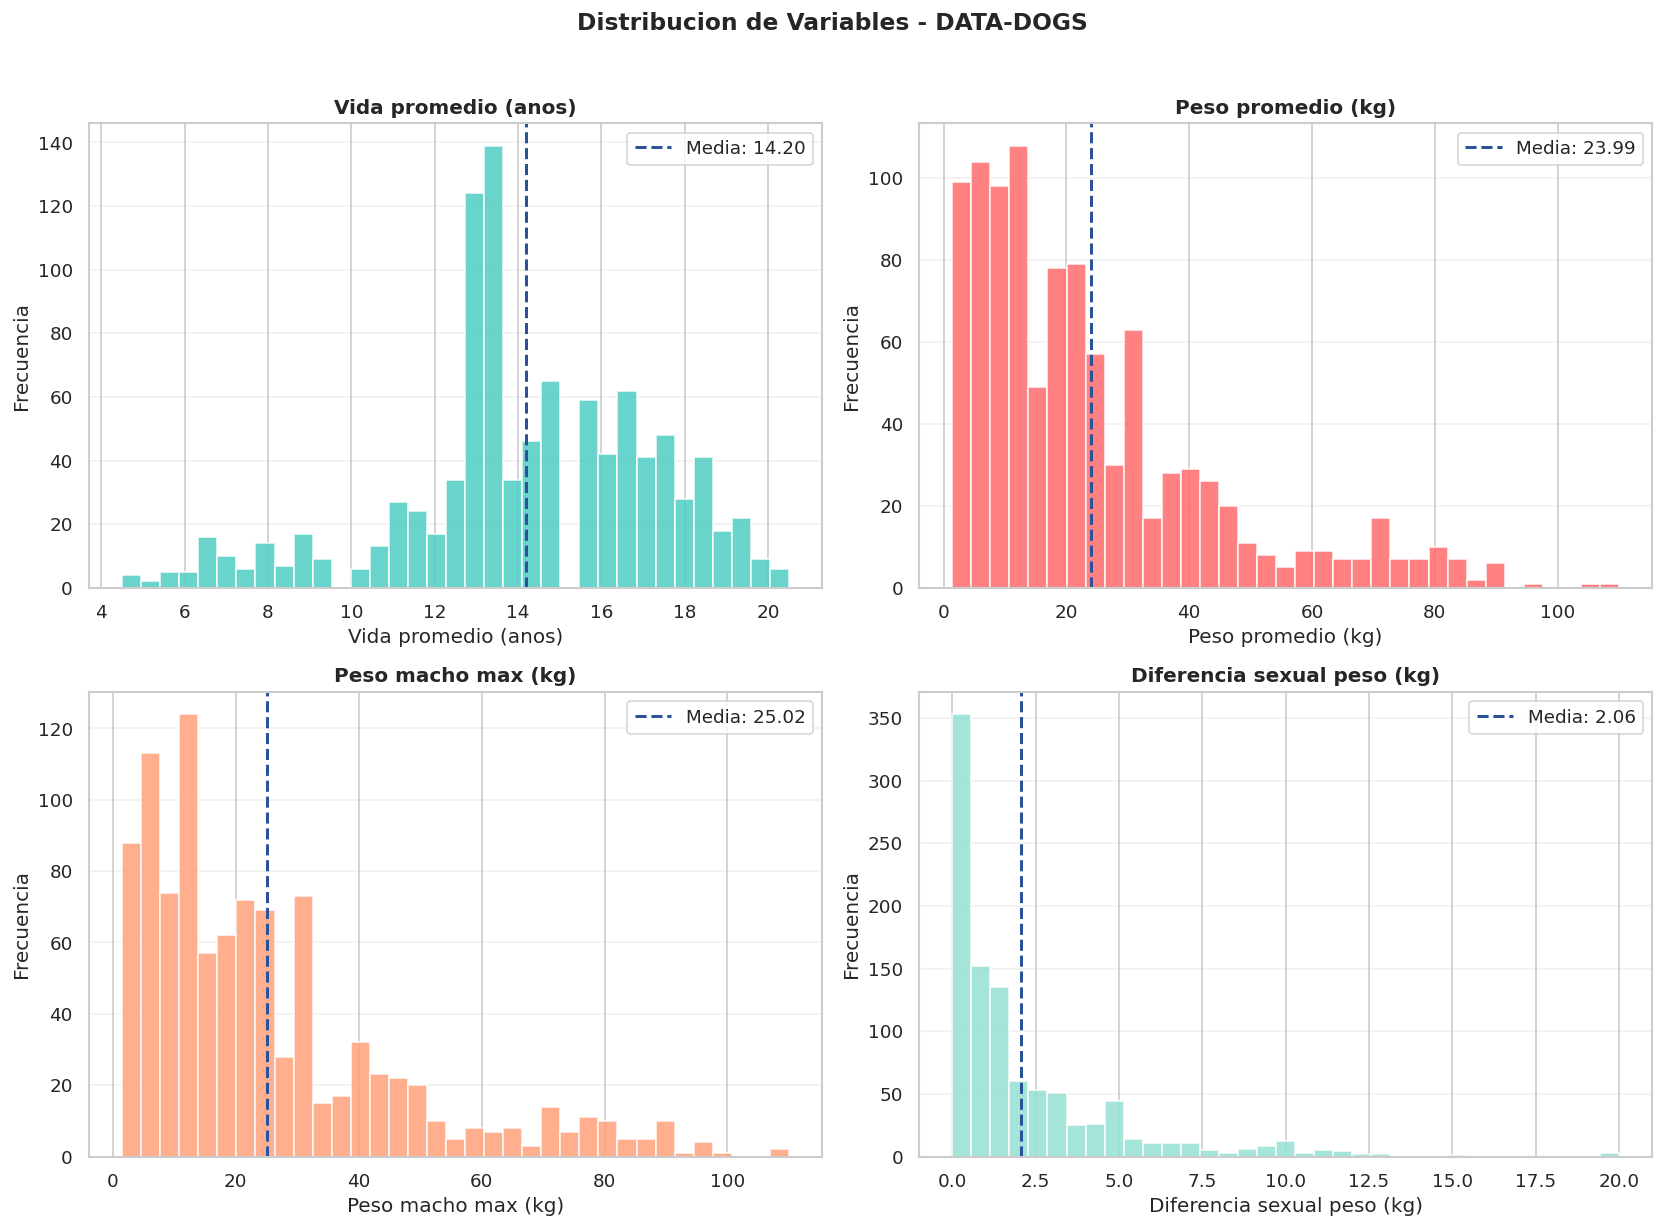

In [8]:
    # CELDA 5 - Histogramas de distribucion (ANTES)
    # 🎯 Objetivo: visualizar distribuciones originales para comparar antes de log1p
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle('Distribucion de Variables - DATA-DOGS', fontsize=14, fontweight='bold', y=1.02)

    datos = {
        'vida_promedio': ('Vida promedio (anos)', '#4ecdc4'),
        'peso_promedio': ('Peso promedio (kg)', '#ff6b6b'),
        'peso_macho_max': ('Peso macho max (kg)', '#ffa07a'),
        'diferencia_sexual_peso': ('Diferencia sexual peso (kg)', '#95e1d3'),
    }

    for ax, (col, (label, color)) in zip(axes.flat, datos.items()):
        ax.hist(df[col].dropna(), bins=35, color=color, edgecolor='white', alpha=0.85)
        media = df[col].mean()
        ax.axvline(media, color='#2a5298', linestyle='--', linewidth=1.8, label=f'Media: {media:.2f}')
        ax.set_title(label, fontweight='bold')
        ax.set_xlabel(label)
        ax.set_ylabel('Frecuencia')
        ax.legend()
        ax.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.savefig('../data/graficas/eda_distribuciones_dogs.png', dpi=150, bbox_inches='tight')
    plt.show()


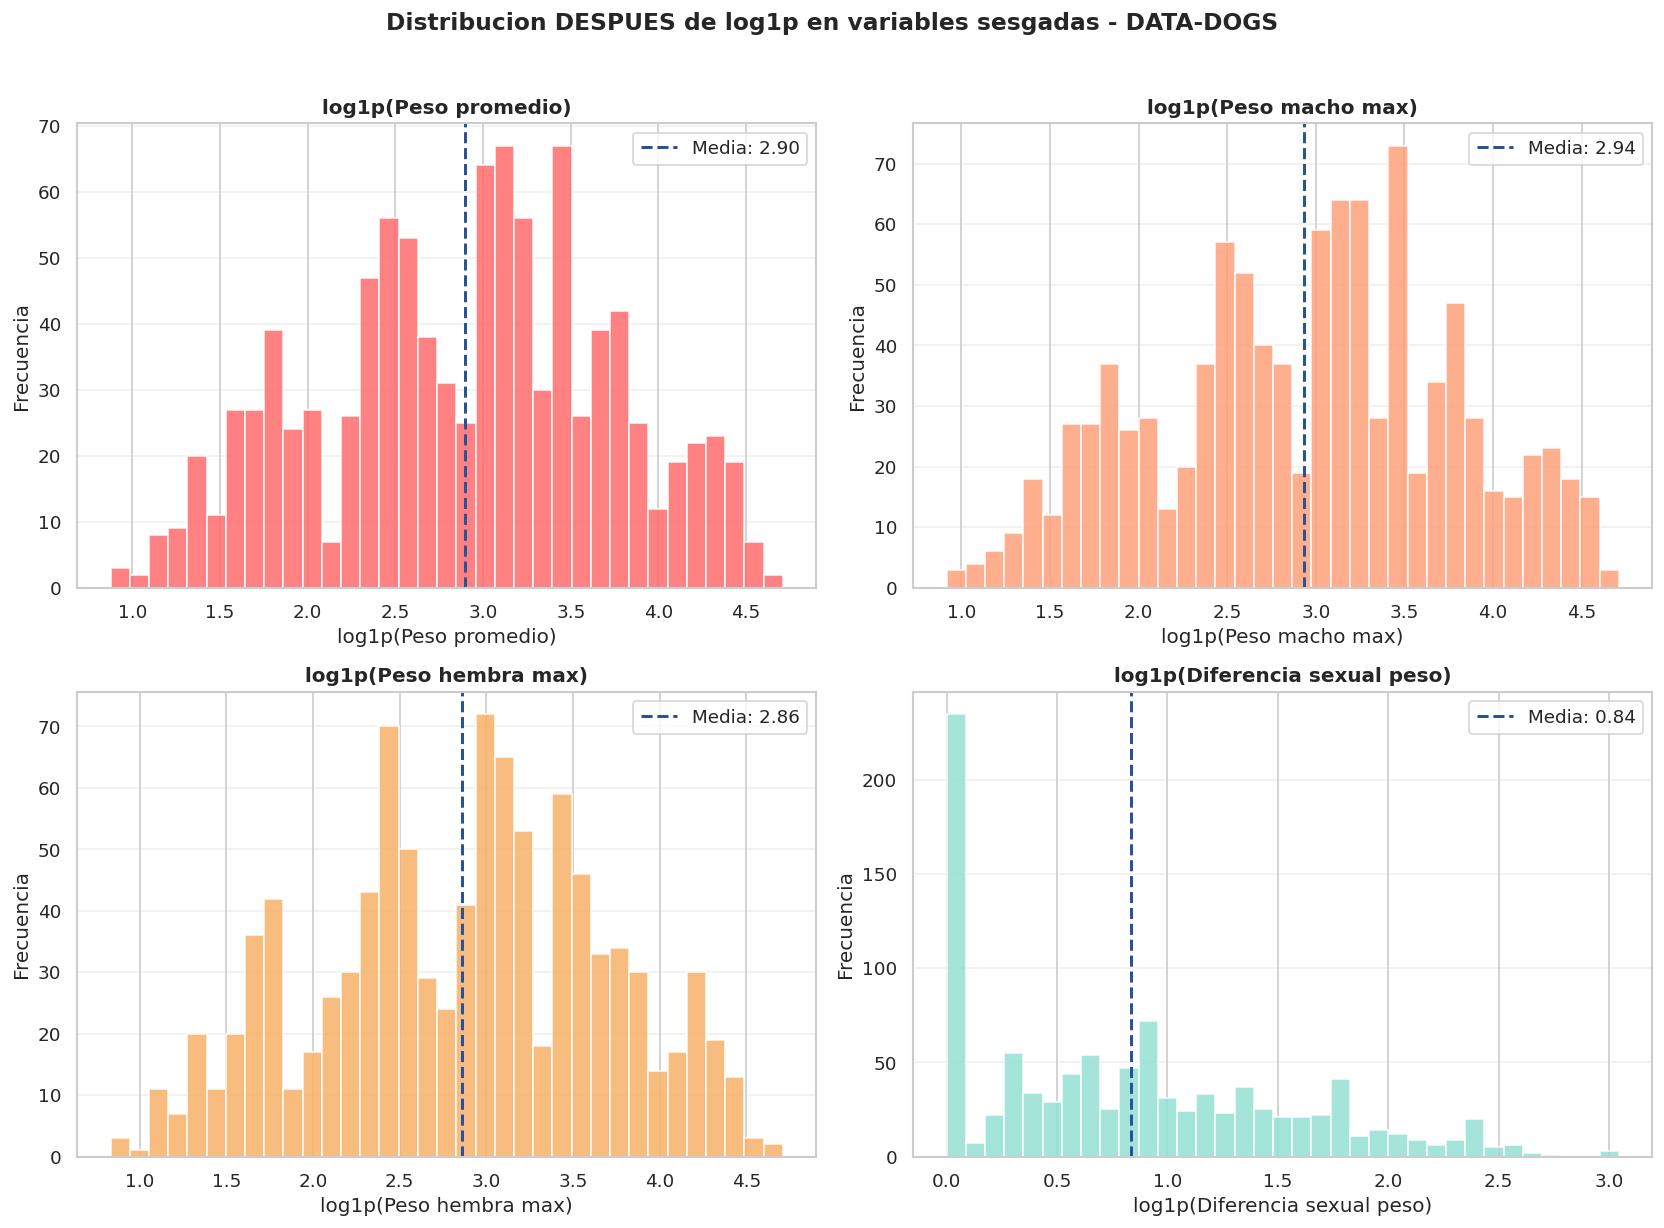

In [9]:
# CELDA 5.1 - Histogramas de distribucion (DESPUES: log1p)
# 🎯 Objetivo: visualizar distribuciones despues de centralizar sesgo
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Distribucion DESPUES de log1p en variables sesgadas - DATA-DOGS', fontsize=14, fontweight='bold', y=1.02)

datos_despues = {
    'log_peso_promedio': ('log1p(Peso promedio)', '#ff6b6b'),
    'log_peso_macho_max': ('log1p(Peso macho max)', '#ffa07a'),
    'log_peso_hembra_max': ('log1p(Peso hembra max)', '#f7b267'),
    'log_diferencia_sexual_peso': ('log1p(Diferencia sexual peso)', '#95e1d3'),
}

for ax, (col, (label, color)) in zip(axes.flat, datos_despues.items()):
    ax.hist(df[col].dropna(), bins=35, color=color, edgecolor='white', alpha=0.85)
    media = df[col].mean()
    ax.axvline(media, color='#2a5298', linestyle='--', linewidth=1.8, label=f'Media: {media:.2f}')
    ax.set_title(label, fontweight='bold')
    ax.set_xlabel(label)
    ax.set_ylabel('Frecuencia')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../data/graficas/eda_distribuciones_dogs_log1p.png', dpi=150, bbox_inches='tight')
plt.show()


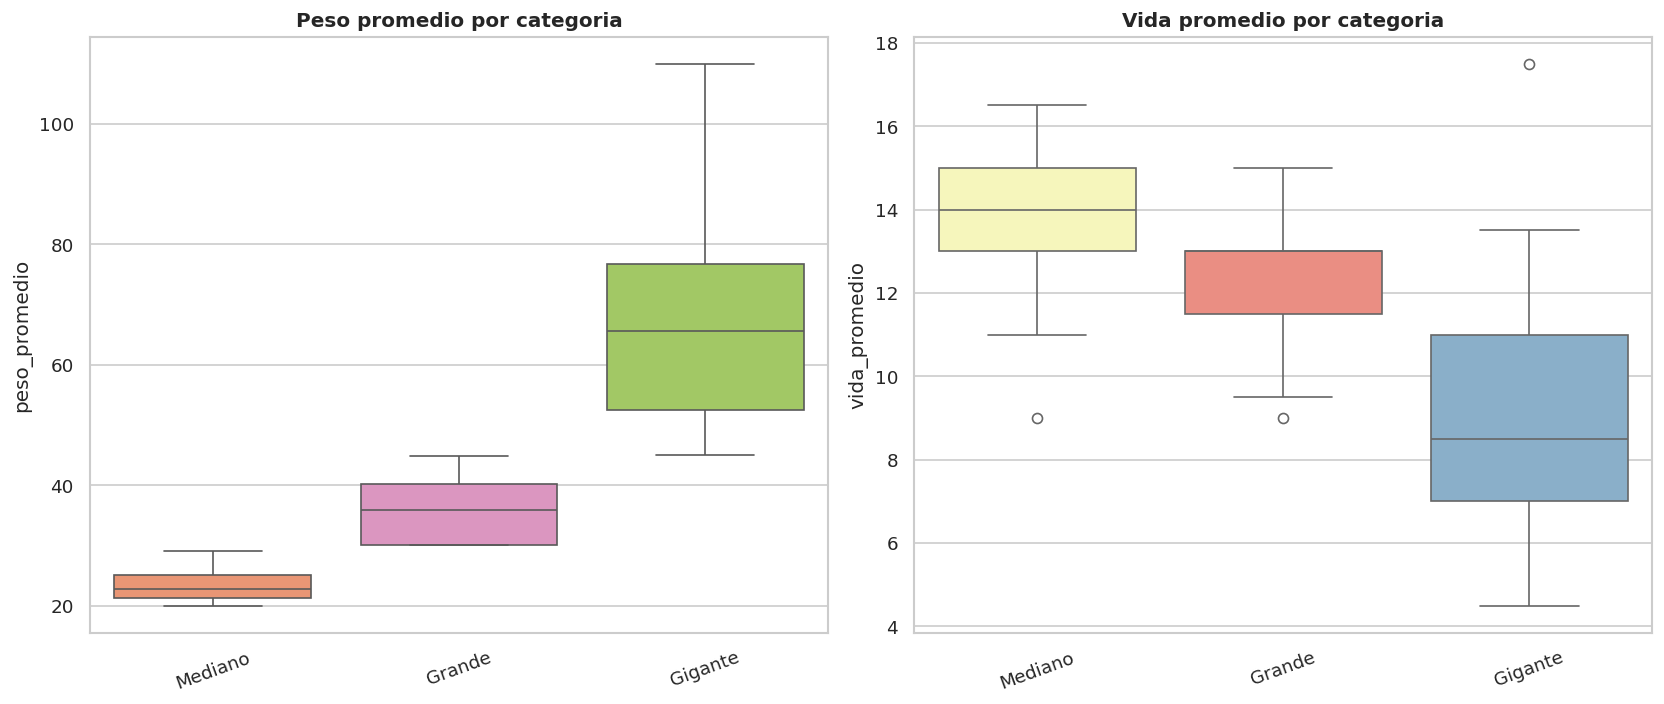

In [10]:
# CELDA 6 - Boxplots por categoria de peso (ANTES)
# 🎯 Objetivo: comparar distribuciones originales por categoria de peso con boxplots
orden = ['Muy pequeno', 'Pequeno', 'Mediano', 'Grande', 'Gigante']
orden_disponible = [c for c in orden if c in df['categoria_peso'].dropna().unique()]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.boxplot(data=df, x='categoria_peso', y='peso_promedio', order=orden_disponible, hue='categoria_peso', palette='Set2', legend=False, ax=axes[0])
axes[0].set_title('Peso promedio por categoria', fontweight='bold')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=20)

sns.boxplot(data=df, x='categoria_peso', y='vida_promedio', order=orden_disponible, hue='categoria_peso', palette='Set3', legend=False, ax=axes[1])
axes[1].set_title('Vida promedio por categoria', fontweight='bold')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.savefig('../data/graficas/eda_boxplots_categoria_dogs.png', dpi=150, bbox_inches='tight')
plt.show()


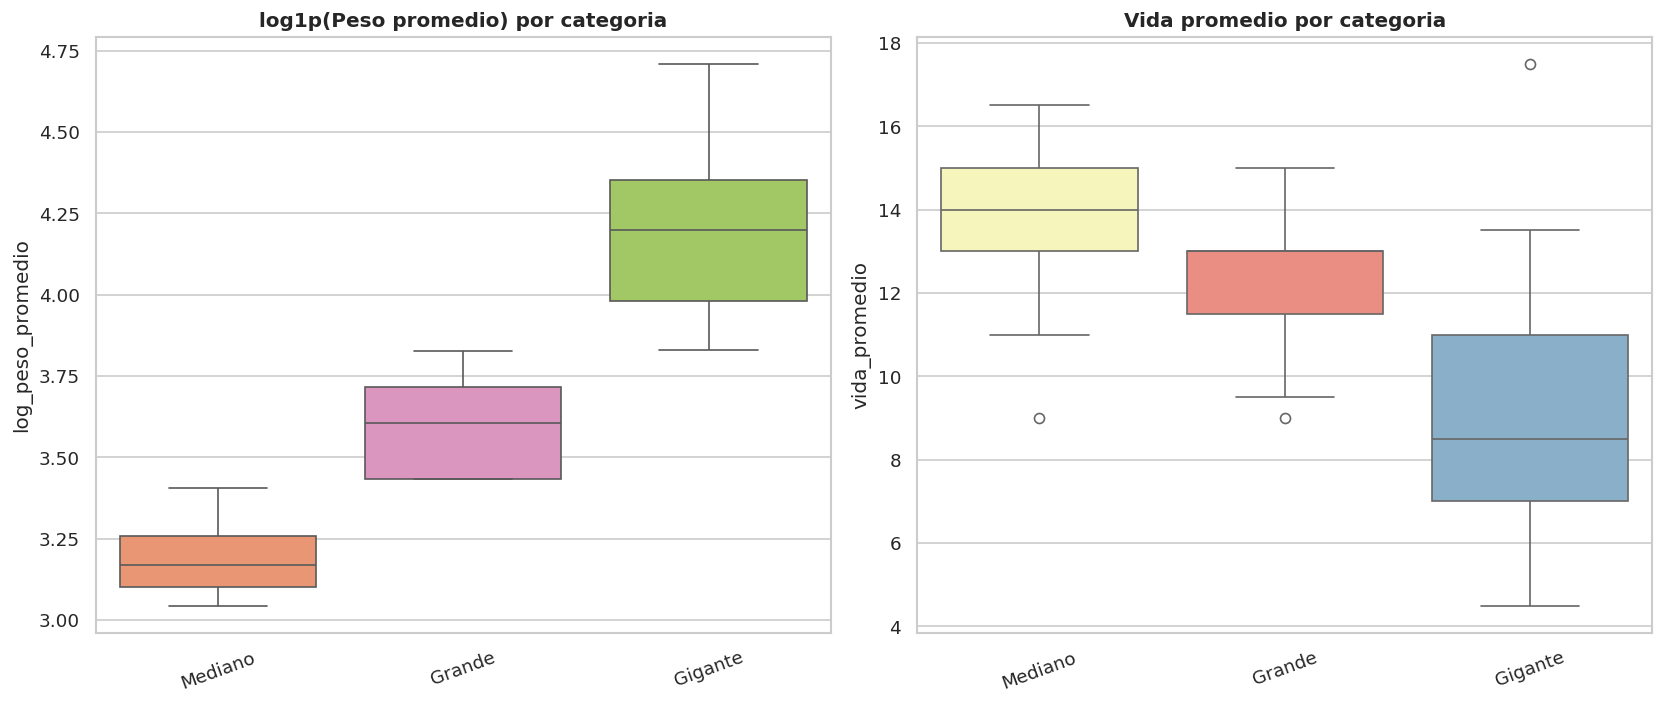

In [11]:
# CELDA 6.1 - Boxplots por categoria de peso (DESPUES: log1p)
# 🎯 Objetivo: comparar distribuciones transformadas por categoria de peso
orden = ['Muy pequeno', 'Pequeno', 'Mediano', 'Grande', 'Gigante']
orden_disponible = [c for c in orden if c in df['categoria_peso'].dropna().unique()]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.boxplot(data=df, x='categoria_peso', y='log_peso_promedio', order=orden_disponible, hue='categoria_peso', palette='Set2', legend=False, ax=axes[0])
axes[0].set_title('log1p(Peso promedio) por categoria', fontweight='bold')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=20)

sns.boxplot(data=df, x='categoria_peso', y='vida_promedio', order=orden_disponible, hue='categoria_peso', palette='Set3', legend=False, ax=axes[1])
axes[1].set_title('Vida promedio por categoria', fontweight='bold')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.savefig('../data/graficas/eda_boxplots_categoria_dogs_log1p.png', dpi=150, bbox_inches='tight')
plt.show()


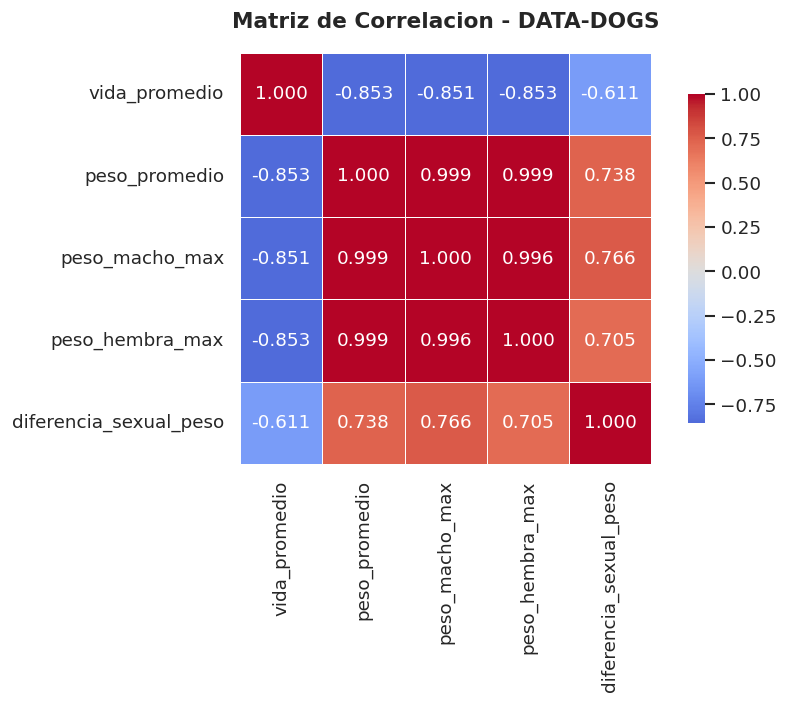


Correlacion con vida_promedio:
diferencia_sexual_peso   -0.6105
peso_macho_max           -0.8507
peso_promedio            -0.8527
peso_hembra_max          -0.8530
Name: vida_promedio, dtype: float64


In [12]:
# CELDA 7 - Matriz de correlacion (ANTES)
# 🎯 Objetivo: medir correlaciones originales entre variables para guiar el modelado
corr = df[vars_num].corr(numeric_only=True)

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr,
    annot=True,
    fmt='.3f',
    cmap='coolwarm',
    center=0,
    linewidths=0.6,
    square=True,
    cbar_kws={'shrink': 0.8}
)
plt.title('Matriz de Correlacion - DATA-DOGS', fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('../data/graficas/eda_correlacion_dogs.png', dpi=150, bbox_inches='tight')
plt.show()

print()
print('Correlacion con vida_promedio:')
print(corr['vida_promedio'].drop('vida_promedio').sort_values(ascending=False).round(4))


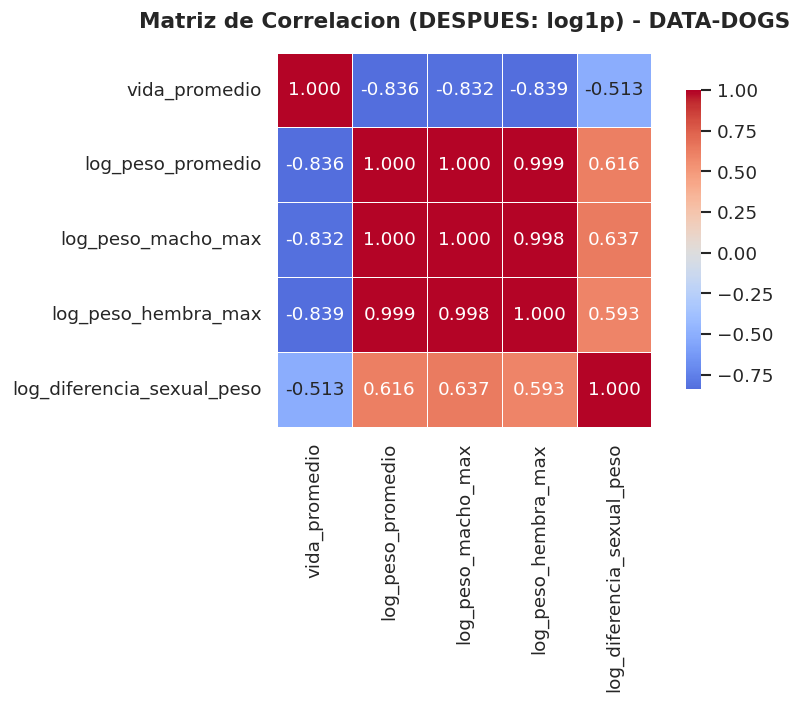


Correlacion con vida_promedio (DESPUES):
log_diferencia_sexual_peso   -0.5135
log_peso_macho_max           -0.8321
log_peso_promedio            -0.8361
log_peso_hembra_max          -0.8394
Name: vida_promedio, dtype: float64


In [13]:
# CELDA 7.1 - Matriz de correlacion (DESPUES: log1p)
# 🎯 Objetivo: medir correlaciones usando variables transformadas (log1p)
vars_num_despues = [
    'vida_promedio',
    'log_peso_promedio',
    'log_peso_macho_max',
    'log_peso_hembra_max',
    'log_diferencia_sexual_peso',
]

corr_despues = df[vars_num_despues].corr(numeric_only=True)

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_despues,
    annot=True,
    fmt='.3f',
    cmap='coolwarm',
    center=0,
    linewidths=0.6,
    square=True,
    cbar_kws={'shrink': 0.8}
)
plt.title('Matriz de Correlacion (DESPUES: log1p) - DATA-DOGS', fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('../data/graficas/eda_correlacion_dogs_log1p.png', dpi=150, bbox_inches='tight')
plt.show()

print()
print('Correlacion con vida_promedio (DESPUES):')
print(corr_despues['vida_promedio'].drop('vida_promedio').sort_values(ascending=False).round(4))


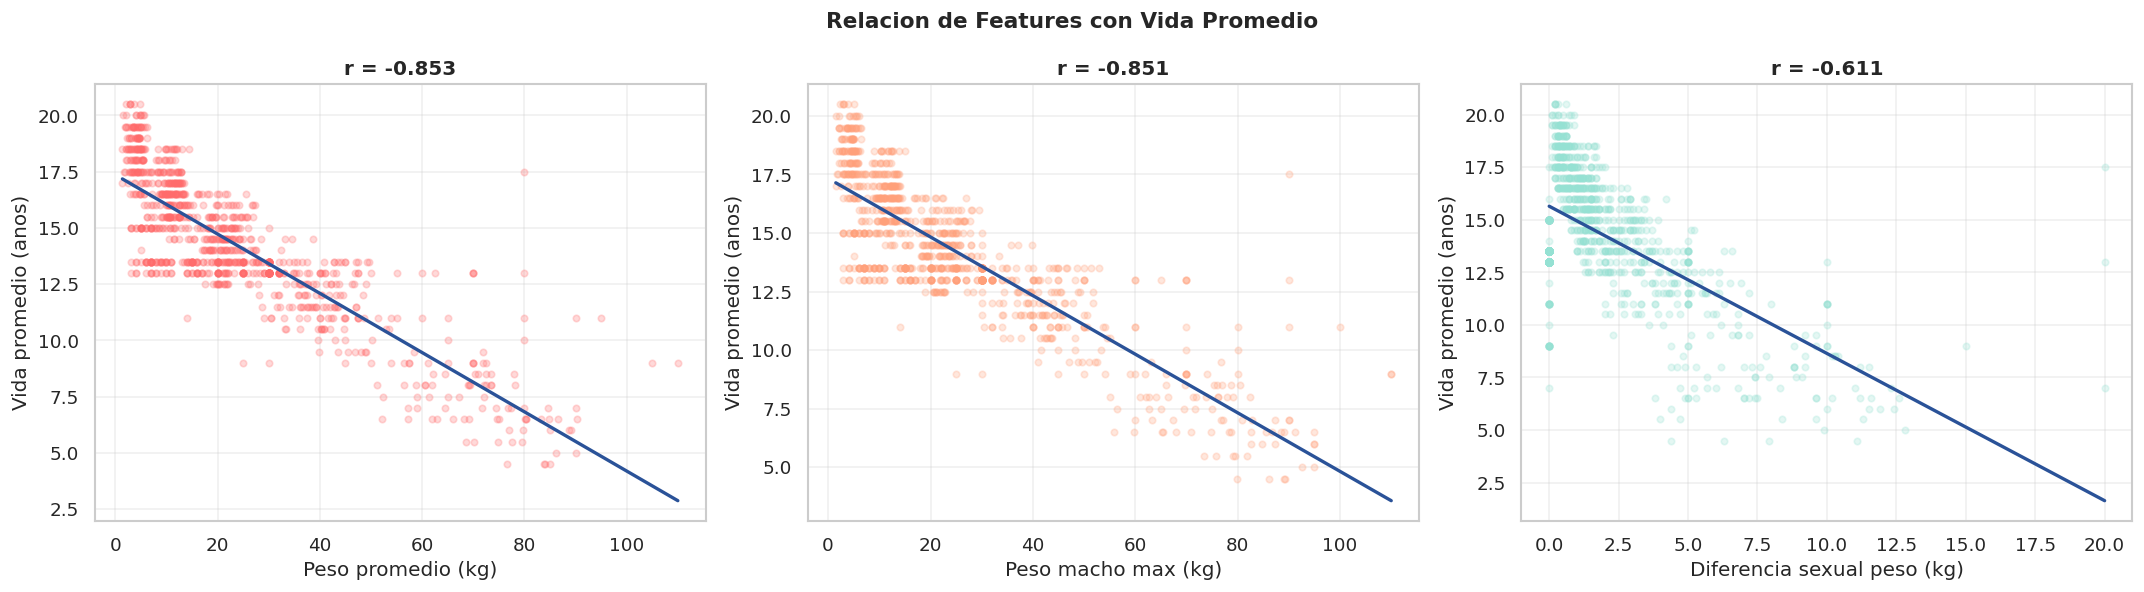

In [14]:
# CELDA 8 - Scatter plots bivariados (ANTES)
# 🎯 Objetivo: evaluar relaciones lineales originales con scatter y tendencia
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Relacion de Features con Vida Promedio', fontsize=13, fontweight='bold')

pares = [
    ('peso_promedio', 'Peso promedio (kg)', '#ff6b6b'),
    ('peso_macho_max', 'Peso macho max (kg)', '#ffa07a'),
    ('diferencia_sexual_peso', 'Diferencia sexual peso (kg)', '#95e1d3'),
]

for ax, (feature, xlabel, color) in zip(axes, pares):
    sub = df[[feature, 'vida_promedio']].dropna()
    ax.scatter(sub[feature], sub['vida_promedio'], alpha=0.25, s=15, color=color)
    z = np.polyfit(sub[feature], sub['vida_promedio'], 1)
    p = np.poly1d(z)
    xp = np.linspace(sub[feature].min(), sub[feature].max(), 200)
    ax.plot(xp, p(xp), color='#2a5298', linewidth=2)
    r = sub.corr().iloc[0, 1]
    ax.set_title(f'r = {r:.3f}', fontweight='bold')
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Vida promedio (anos)')
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../data/graficas/eda_scatter_dogs.png', dpi=150, bbox_inches='tight')
plt.show()


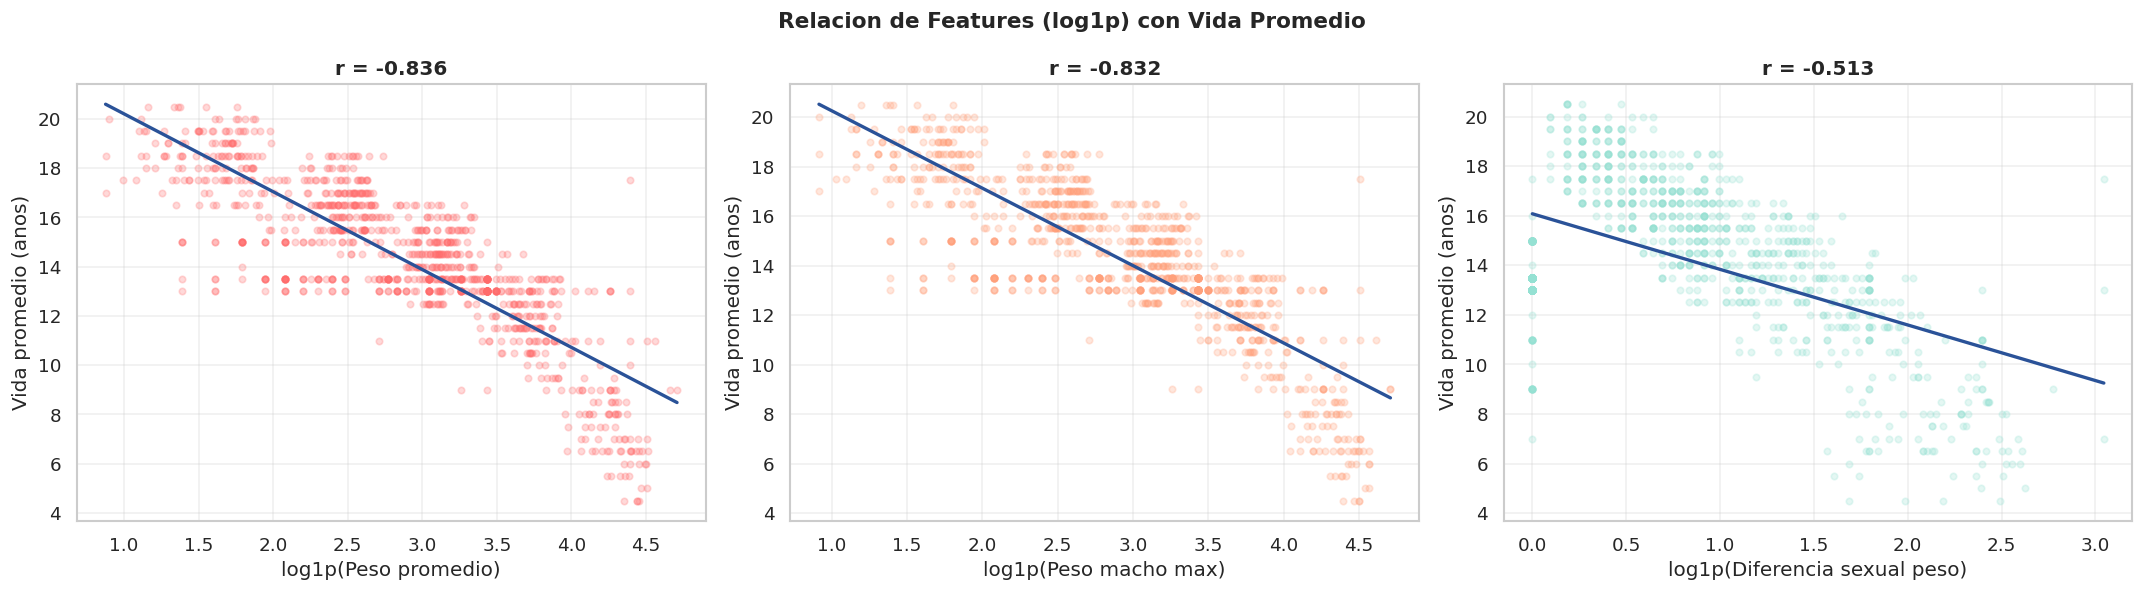

In [15]:
# CELDA 8.1 - Scatter plots bivariados (DESPUES: log1p)
# 🎯 Objetivo: evaluar relaciones lineales usando variables transformadas (log1p)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Relacion de Features (log1p) con Vida Promedio', fontsize=13, fontweight='bold')

pares = [
    ('log_peso_promedio', 'log1p(Peso promedio)', '#ff6b6b'),
    ('log_peso_macho_max', 'log1p(Peso macho max)', '#ffa07a'),
    ('log_diferencia_sexual_peso', 'log1p(Diferencia sexual peso)', '#95e1d3'),
]

for ax, (feature, xlabel, color) in zip(axes, pares):
    sub = df[[feature, 'vida_promedio']].dropna()
    ax.scatter(sub[feature], sub['vida_promedio'], alpha=0.25, s=15, color=color)
    z = np.polyfit(sub[feature], sub['vida_promedio'], 1)
    p = np.poly1d(z)
    xp = np.linspace(sub[feature].min(), sub[feature].max(), 200)
    ax.plot(xp, p(xp), color='#2a5298', linewidth=2)
    r = sub.corr(numeric_only=True).iloc[0, 1]
    ax.set_title(f'r = {r:.3f}', fontweight='bold')
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Vida promedio (anos)')
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../data/graficas/eda_scatter_dogs_log1p.png', dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
# CELDA 9 - Train/Test para modelo simple
# 🎯 Objetivo: separar 80/20 y preparar codificacion de variables categoricas
TARGET = 'diferencia_sexual_peso'
FEATURES_SIMPLE = ['vida_promedio', 'categoria_peso']

X_simple = df[FEATURES_SIMPLE].copy()
y = df[TARGET].values

X_train, X_test, y_train, y_test = train_test_split(
    X_simple, y, test_size=0.20, random_state=42
)

num_features = ['vida_promedio']
cat_features = ['categoria_peso']

preprocess_simple = ColumnTransformer([
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
    ]), num_features),
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore')),
    ]), cat_features),
])

print(f'Target: {TARGET}')
print(f'Features: {FEATURES_SIMPLE}')
print(f'Train: {X_train.shape[0]:,} muestras ({X_train.shape[0]/len(y)*100:.0f}%)')
print(f'Test : {X_test.shape[0]:,} muestras ({X_test.shape[0]/len(y)*100:.0f}%)')
print('Preprocesamiento listo: imputacion + escalado numerico + one-hot categorico')


In [ ]:
# CELDA 10 - Entrenamiento regresion simple
# 🎯 Objetivo: entrenar regresion lineal simple con preprocesamiento (num + categoricas)
modelo_simple = Pipeline([
    ('preprocess', preprocess_simple),
    ('model', LinearRegression()),
])

modelo_simple.fit(X_train, y_train)
y_pred_simple = modelo_simple.predict(X_test)

modelo_lineal = modelo_simple.named_steps['model']
feature_names = modelo_simple.named_steps['preprocess'].get_feature_names_out()
coef_df = pd.DataFrame({
    'feature': feature_names,
    'coeficiente': modelo_lineal.coef_,
}).sort_values('coeficiente', key=np.abs, ascending=False)

print(f'Intercepto b0: {modelo_lineal.intercept_:.4f}')
print('Top coeficientes por magnitud:')
print(coef_df.head(10).to_string(index=False))
print()
print('Modelo entrenado correctamente para TARGET = diferencia_sexual_peso')


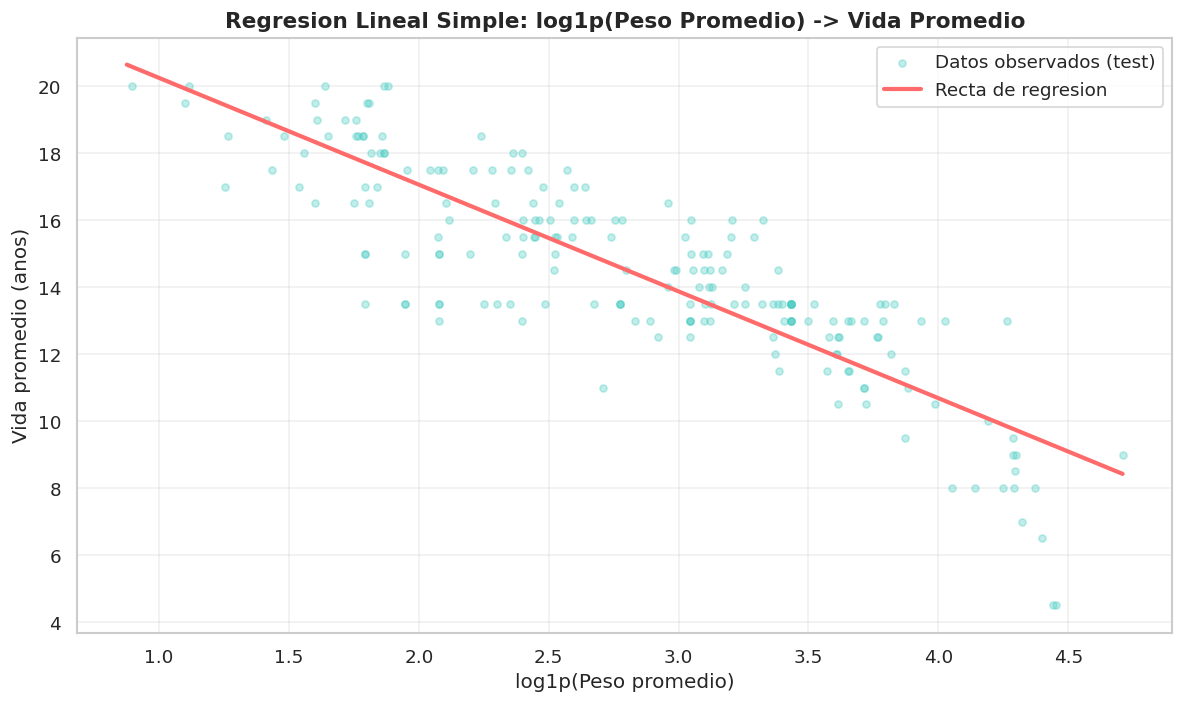

In [18]:
# CELDA 11 - Visualizacion de recta de regresion simple
# 🎯 Objetivo: mostrar la recta ajustada frente a datos reales
fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(X_test, y_test, alpha=0.35, s=18, color='#4ecdc4', label='Datos observados (test)')
x_line = np.linspace(X_simple.min(), X_simple.max(), 300).reshape(-1, 1)
ax.plot(x_line, modelo_simple.predict(x_line), color='#ff6b6b', linewidth=2.5, label='Recta de regresion')

ax.set_xlabel('log1p(Peso promedio)', fontsize=12)
ax.set_ylabel('Vida promedio (anos)', fontsize=12)
ax.set_title('Regresion Lineal Simple: log1p(Peso Promedio) -> Vida Promedio', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../data/graficas/regresion_simple_dogs.png', dpi=150, bbox_inches='tight')
plt.show()


In [20]:
# CELDA 12 - Metricas modelo simple
# 🎯 Objetivo: calcular metricas base del modelo simple
r2 = r2_score(y_test, y_pred_simple)
mse = mean_squared_error(y_test, y_pred_simple)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred_simple)

print('=' * 52)
print('📈 METRICAS - REGRESION LINEAL SIMPLE')
print('=' * 52)
print(f'🎯 R2   : {r2:.4f} ({r2*100:.2f}%)')
print(f'📉 MSE  : {mse:.4f}')
print(f'📏 RMSE : {rmse:.4f}')
print(f'🧮 MAE  : {mae:.4f}')
print('=' * 52)


📈 METRICAS - REGRESION LINEAL SIMPLE
🎯 R2   : 0.7252 (72.52%)
📉 MSE  : 2.4503
📏 RMSE : 1.5653
🧮 MAE  : 1.2385


In [22]:
# CELDA 13 - Resumen OLS modelo simple
# 🎯 Objetivo: obtener inferencia estadistica OLS del modelo simple
X_ols = sm.add_constant(df[feature_simple])
modelo_ols_simple = sm.OLS(df['vida_promedio'], X_ols).fit()
print(modelo_ols_simple.summary())


                            OLS Regression Results                            
Dep. Variable:          vida_promedio   R-squared:                       0.699
Model:                            OLS   Adj. R-squared:                  0.699
Method:                 Least Squares   F-statistic:                     2318.
Date:                Thu, 16 Apr 2026   Prob (F-statistic):          1.85e-262
Time:                        06:53:43   Log-Likelihood:                -1958.4
No. Observations:                1000   AIC:                             3921.
Df Residuals:                     998   BIC:                             3931.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                23.3583      0.19

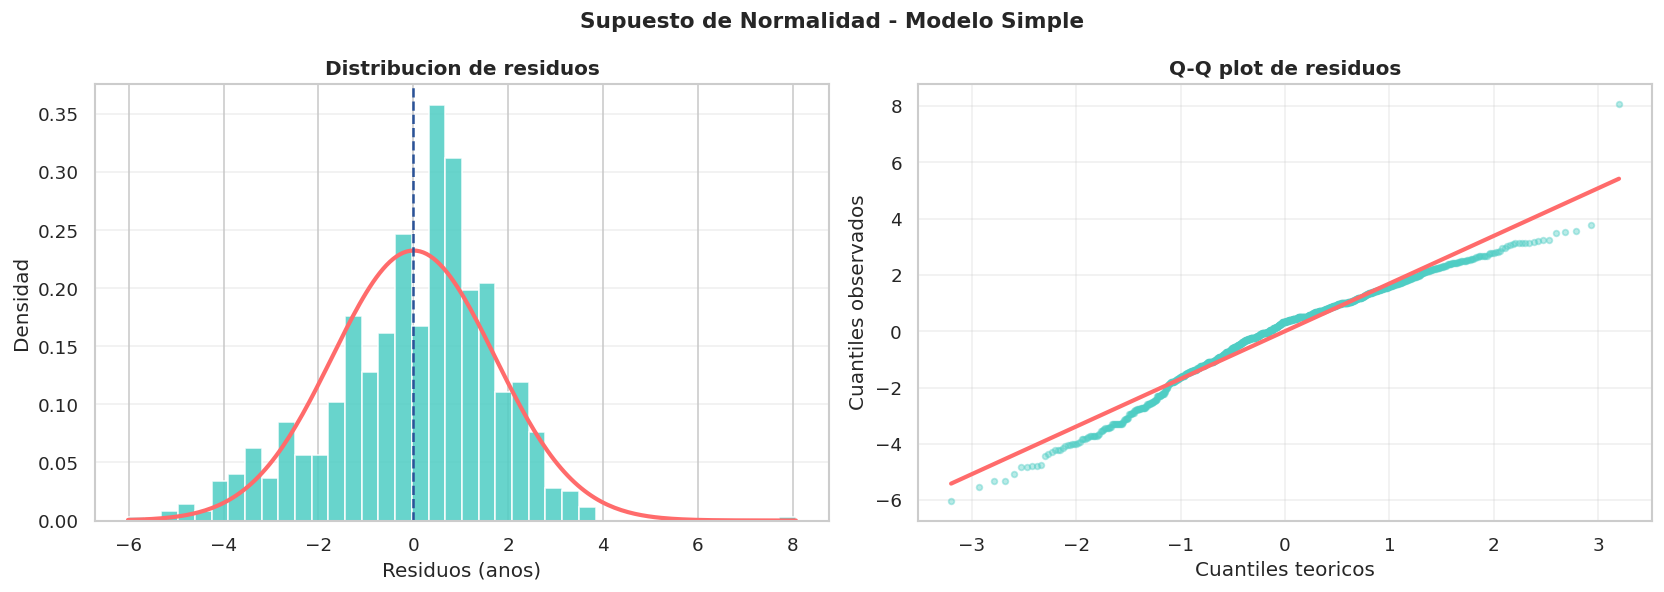


Test de Shapiro-Wilk:
W       : 0.9704
p-value : 0.000000
Conclusion: Se rechaza normalidad


In [25]:
# CELDA 14 - Normalidad de residuos (simple)
# 🎯 Objetivo: verificar normalidad de residuos del modelo simple
y_pred_all = modelo_simple.predict(df[[feature_simple]].values)
residuos = df['vida_promedio'].values - y_pred_all

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Supuesto de Normalidad - Modelo Simple', fontsize=13, fontweight='bold')

axes[0].hist(residuos, bins=40, color='#4ecdc4', edgecolor='white', density=True, alpha=0.85)
xr = np.linspace(residuos.min(), residuos.max(), 200)
axes[0].plot(xr, stats.norm.pdf(xr, residuos.mean(), residuos.std()), color='#ff6b6b', linewidth=2.5)
axes[0].axvline(0, color='#2a5298', linestyle='--', linewidth=1.5)
axes[0].set_title('Distribucion de residuos', fontweight='bold')
axes[0].set_xlabel('Residuos (anos)')
axes[0].set_ylabel('Densidad')
axes[0].grid(axis='y', alpha=0.3)

(osm, osr), (slope, intercept, _) = stats.probplot(residuos, dist='norm')
axes[1].scatter(osm, osr, alpha=0.4, s=12, color='#4ecdc4')
axes[1].plot(osm, slope * np.array(osm) + intercept, color='#ff6b6b', linewidth=2.5)
axes[1].set_title('Q-Q plot de residuos', fontweight='bold')
axes[1].set_xlabel('Cuantiles teoricos')
axes[1].set_ylabel('Cuantiles observados')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../data/graficas/normalidad_simple_dogs.png', dpi=150, bbox_inches='tight')
plt.show()

muestra_sw = residuos if len(residuos) <= 5000 else np.random.default_rng(42).choice(residuos, 5000, replace=False)
stat_sw, p_sw = stats.shapiro(muestra_sw)

print()
print('Test de Shapiro-Wilk:')
print(f'W       : {stat_sw:.4f}')
print(f'p-value : {p_sw:.6f}')
print('Conclusion:', 'No se rechaza normalidad' if p_sw > 0.05 else 'Se rechaza normalidad')


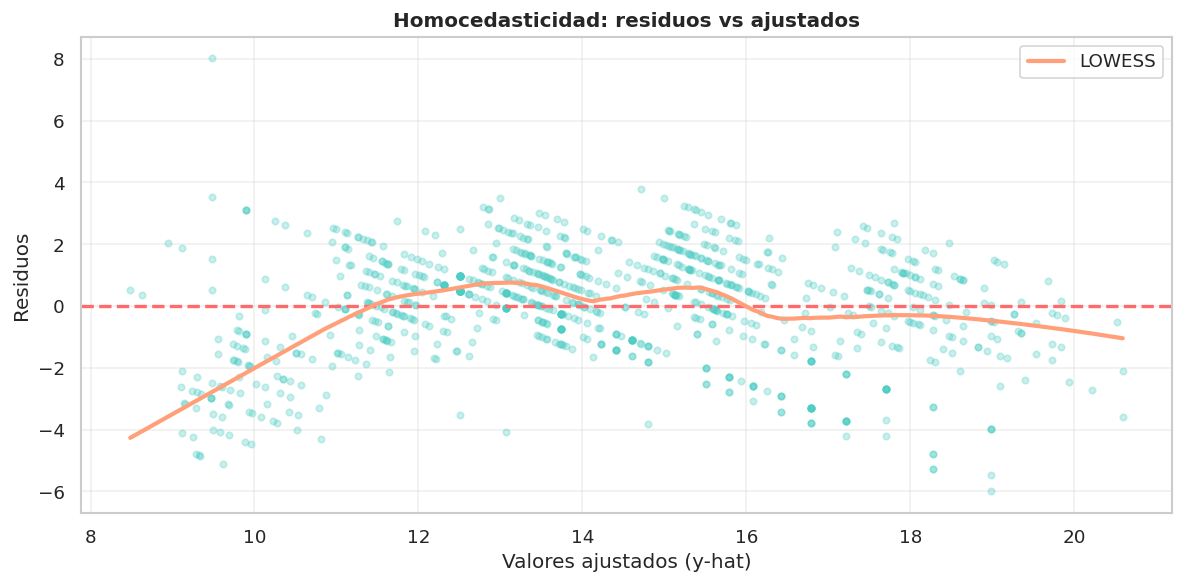


Test de Breusch-Pagan:
LM      : 3.5501
p-value : 0.059543
Conclusion: Homocedasticidad OK


In [27]:
# CELDA 15 - Homocedasticidad (simple)
# 🎯 Objetivo: evaluar homocedasticidad con residuos y Breusch-Pagan
residuos_ols = modelo_ols_simple.resid
ajustados_ols = modelo_ols_simple.fittedvalues

plt.figure(figsize=(10, 5))
plt.scatter(ajustados_ols, residuos_ols, alpha=0.30, s=15, color='#4ecdc4')
plt.axhline(0, color='#ff6b6b', linestyle='--', linewidth=2)
lowess = sm.nonparametric.lowess(residuos_ols, ajustados_ols, frac=0.3)
plt.plot(lowess[:, 0], lowess[:, 1], color='#ffa07a', linewidth=2.5, label='LOWESS')
plt.xlabel('Valores ajustados (y-hat)')
plt.ylabel('Residuos')
plt.title('Homocedasticidad: residuos vs ajustados', fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../data/graficas/homoc_simple_dogs.png', dpi=150, bbox_inches='tight')
plt.show()

lm, lm_p, fval, fp = het_breuschpagan(residuos_ols, modelo_ols_simple.model.exog)

print()
print('Test de Breusch-Pagan:')
print(f'LM      : {lm:.4f}')
print(f'p-value : {lm_p:.6f}')
print('Conclusion:', 'Homocedasticidad OK' if lm_p > 0.05 else 'Heterocedasticidad detectada')


In [29]:
# CELDA 16 - Preparacion y entrenamiento modelo multiple
# 🎯 Objetivo: entrenar modelo de regresion lineal multiple con variables transformadas
FEATURES = ['log_peso_promedio', 'log_diferencia_sexual_peso']

X_multi = df[FEATURES].values
y = df['vida_promedio'].values

X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_multi, y, test_size=0.20, random_state=42
)

modelo_multi = LinearRegression()
modelo_multi.fit(X_train_m, y_train_m)

y_pred_multi = modelo_multi.predict(X_test_m)

print(f'Intercepto  b0 : {modelo_multi.intercept_:.4f}')
for feat, coef in zip(FEATURES, modelo_multi.coef_):
    print(f'Coeficiente {feat:>24}: {coef:.4f}')


Intercepto  b0 : 23.4272
Coeficiente        log_peso_promedio: -3.1811
Coeficiente log_diferencia_sexual_peso: -0.0099


In [ ]:
# CELDA 17 - Grafica de coeficientes (multiple)
# Objetivo: visualizar importancia relativa de coeficientes del modelo multiple
if 'pipe_multi' not in globals():
    raise NameError('No existe pipe_multi. Ejecuta primero las celdas 16 y 16.1.')

modelo = pipe_multi.named_steps['model']
pre = pipe_multi.named_steps['preprocess']

try:
    feature_names = pre.get_feature_names_out()
except Exception:
    feature_names = np.array([f'feature_{i}' for i in range(len(modelo.coef_))])

coef_df = pd.DataFrame({
    'feature': feature_names,
    'coeficiente': modelo.coef_
}).sort_values('coeficiente')

plt.figure(figsize=(10, 6))
colors = np.where(coef_df['coeficiente'] >= 0, '#4ecdc4', '#ff6b6b')
plt.barh(coef_df['feature'], coef_df['coeficiente'], color=colors, alpha=0.9)
plt.axvline(0, color='#2a5298', linestyle='--', linewidth=1.5)
plt.title('Coeficientes del Modelo de Regresion Multiple', fontweight='bold')
plt.xlabel('Valor del coeficiente')
plt.ylabel('Variable')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('../data/graficas/coeficientes_modelo_multiple_dogs.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top coeficientes (valor absoluto):')
display(coef_df.assign(abs_coef=np.abs(coef_df['coeficiente']))
        .sort_values('abs_coef', ascending=False)
        .drop(columns='abs_coef')
        .head(10))


In [31]:
# CELDA 18 - Metricas modelo multiple
# 🎯 Objetivo: calcular metricas de rendimiento del modelo multiple
r2_m = r2_score(y_test_m, y_pred_multi)
mse_m = mean_squared_error(y_test_m, y_pred_multi)
rmse_m = np.sqrt(mse_m)
mae_m = mean_absolute_error(y_test_m, y_pred_multi)

print('=' * 52)
print('📈 METRICAS - REGRESION LINEAL MULTIPLE')
print('=' * 52)
print(f'🎯 R2   : {r2_m:.4f} ({r2_m*100:.2f}%)')
print(f'📉 MSE  : {mse_m:.4f}')
print(f'📏 RMSE : {rmse_m:.4f}')
print(f'🧮 MAE  : {mae_m:.4f}')
print('=' * 52)


📈 METRICAS - REGRESION LINEAL MULTIPLE
🎯 R2   : 0.7252 (72.52%)
📉 MSE  : 2.4510
📏 RMSE : 1.5656
🧮 MAE  : 1.2385


In [32]:
# CELDA 19 - Resumen OLS multiple
# 🎯 Objetivo: obtener inferencia estadistica OLS del modelo multiple
X_ols_m = sm.add_constant(df[FEATURES])
modelo_ols_multi = sm.OLS(df['vida_promedio'], X_ols_m).fit()
print(modelo_ols_multi.summary())


                            OLS Regression Results                            
Dep. Variable:          vida_promedio   R-squared:                       0.699
Model:                            OLS   Adj. R-squared:                  0.698
Method:                 Least Squares   F-statistic:                     1158.
Date:                Thu, 16 Apr 2026   Prob (F-statistic):          1.11e-260
Time:                        07:01:54   Log-Likelihood:                -1958.4
No. Observations:                1000   AIC:                             3923.
Df Residuals:                     997   BIC:                             3938.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const               

In [33]:
# CELDA 20 - VIF multicolinealidad
# 🎯 Objetivo: medir multicolinealidad mediante VIF
X_vif = df[FEATURES].copy()

vif_data = pd.DataFrame({
    'Variable': FEATURES,
    'VIF': [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
})
vif_data['VIF'] = vif_data['VIF'].round(3)
vif_data['Criterio'] = vif_data['VIF'].apply(
    lambda v: '✅ Sin multicolinealidad (VIF < 5)' if v < 5
    else ('⚠️ Moderada (5 <= VIF < 10)' if v < 10 else '❌ Severa (VIF >= 10)')
)

print('🔎 FACTOR DE INFLACIÓN DE LA VARIANZA (VIF)')
print('=' * 70)
print(vif_data.to_string(index=False))
print('=' * 70)


🔎 FACTOR DE INFLACIÓN DE LA VARIANZA (VIF)
                  Variable   VIF                          Criterio
         log_peso_promedio 3.408 ✅ Sin multicolinealidad (VIF < 5)
log_diferencia_sexual_peso 3.408 ✅ Sin multicolinealidad (VIF < 5)


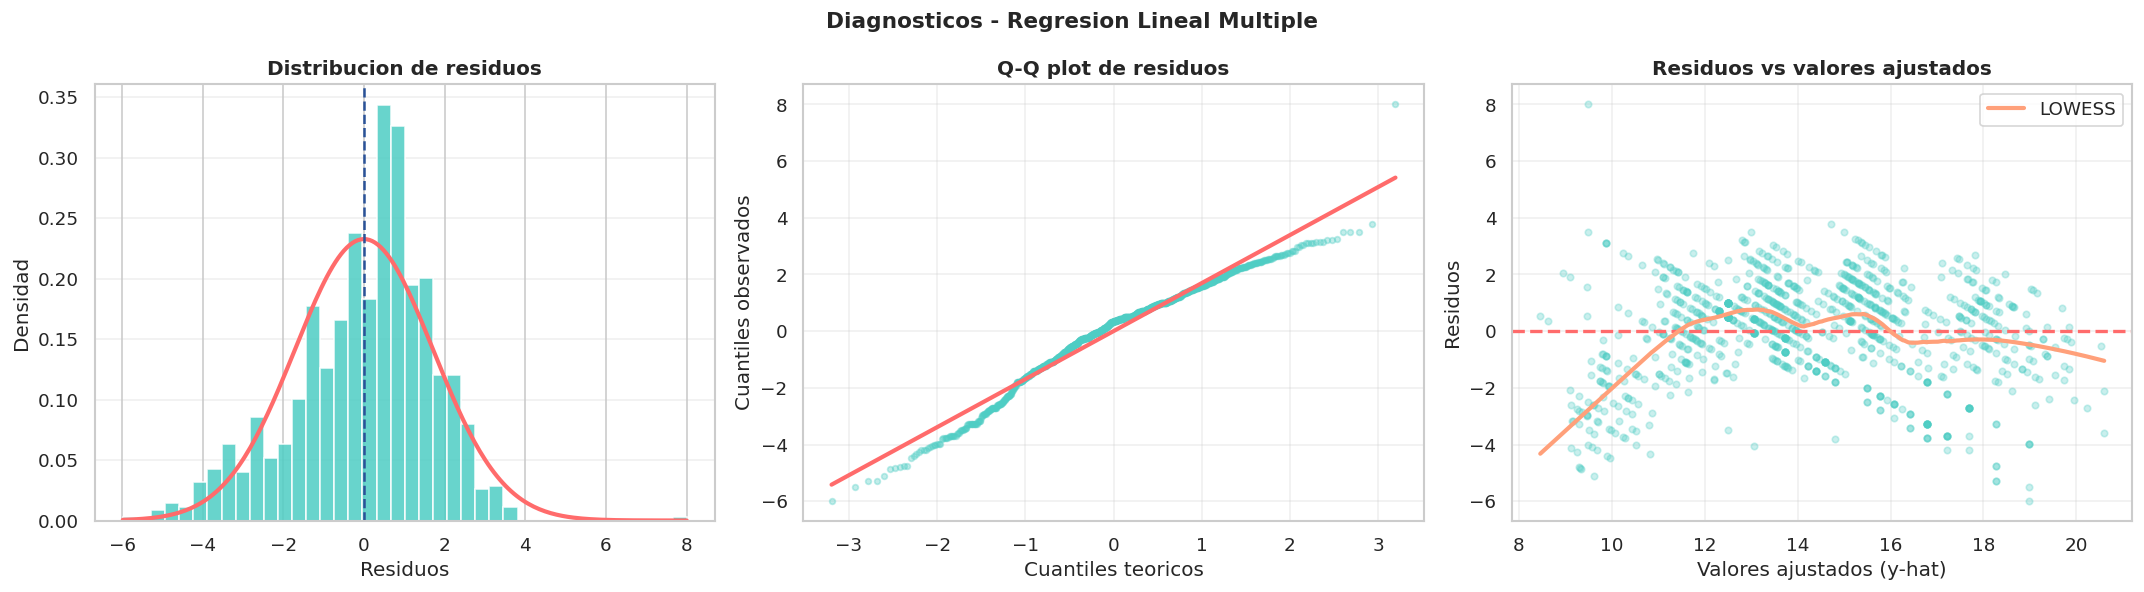


Test Shapiro-Wilk (normalidad):
p-value: 0.000000
Conclusion: Se rechaza normalidad

Test Breusch-Pagan (homocedasticidad):
p-value: 0.000421
Conclusion: Heterocedasticidad detectada


In [37]:
# CELDA 21 - Diagnosticos completos modelo multiple
# 🎯 Objetivo: evaluar diagnosticos del modelo multiple
residuos_m = modelo_ols_multi.resid.values
ajustados_m = modelo_ols_multi.fittedvalues.values

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Diagnosticos - Regresion Lineal Multiple', fontsize=13, fontweight='bold')

axes[0].hist(residuos_m, bins=40, color='#4ecdc4', edgecolor='white', density=True, alpha=0.85)
xr = np.linspace(residuos_m.min(), residuos_m.max(), 200)
axes[0].plot(xr, stats.norm.pdf(xr, residuos_m.mean(), residuos_m.std()), color='#ff6b6b', linewidth=2.5)
axes[0].axvline(0, color='#2a5298', linestyle='--')
axes[0].set_title('Distribucion de residuos', fontweight='bold')
axes[0].set_xlabel('Residuos')
axes[0].set_ylabel('Densidad')
axes[0].grid(axis='y', alpha=0.3)

(osm, osr), (s, i, _) = stats.probplot(residuos_m, dist='norm')
axes[1].scatter(osm, osr, alpha=0.35, s=12, color='#4ecdc4')
axes[1].plot(osm, s * np.array(osm) + i, color='#ff6b6b', linewidth=2.5)
axes[1].set_title('Q-Q plot de residuos', fontweight='bold')
axes[1].set_xlabel('Cuantiles teoricos')
axes[1].set_ylabel('Cuantiles observados')
axes[1].grid(alpha=0.3)

axes[2].scatter(ajustados_m, residuos_m, alpha=0.30, s=15, color='#4ecdc4')
axes[2].axhline(0, color='#ff6b6b', linestyle='--', linewidth=2)
lowess_m = sm.nonparametric.lowess(residuos_m, ajustados_m, frac=0.3)
axes[2].plot(lowess_m[:, 0], lowess_m[:, 1], color='#ffa07a', linewidth=2.5, label='LOWESS')
axes[2].set_title('Residuos vs valores ajustados', fontweight='bold')
axes[2].set_xlabel('Valores ajustados (y-hat)')
axes[2].set_ylabel('Residuos')
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../data/graficas/diagnosticos_multi_dogs.png', dpi=150, bbox_inches='tight')
plt.show()

muestra_m = residuos_m if len(residuos_m) <= 5000 else np.random.default_rng(42).choice(residuos_m, 5000, replace=False)
stat_sw_m, p_sw_m = stats.shapiro(muestra_m)
lm_m, lm_p_m, _, _ = het_breuschpagan(modelo_ols_multi.resid, modelo_ols_multi.model.exog)

print()
print('Test Shapiro-Wilk (normalidad):')
print(f'p-value: {p_sw_m:.6f}')
print('Conclusion:', 'No se rechaza normalidad' if p_sw_m > 0.05 else 'Se rechaza normalidad')

print()
print('Test Breusch-Pagan (homocedasticidad):')
print(f'p-value: {lm_p_m:.6f}')
print('Conclusion:', 'Homocedasticidad OK' if lm_p_m > 0.05 else 'Heterocedasticidad detectada')


📈 METRICAS - MULTIPLE con log(y) (evaluadas en escala original)
Features: ['log_peso_promedio', 'log_diferencia_sexual_peso']
🎯 R2   : 0.6485
📏 RMSE : 1.7704
🧮 MAE  : 1.4210


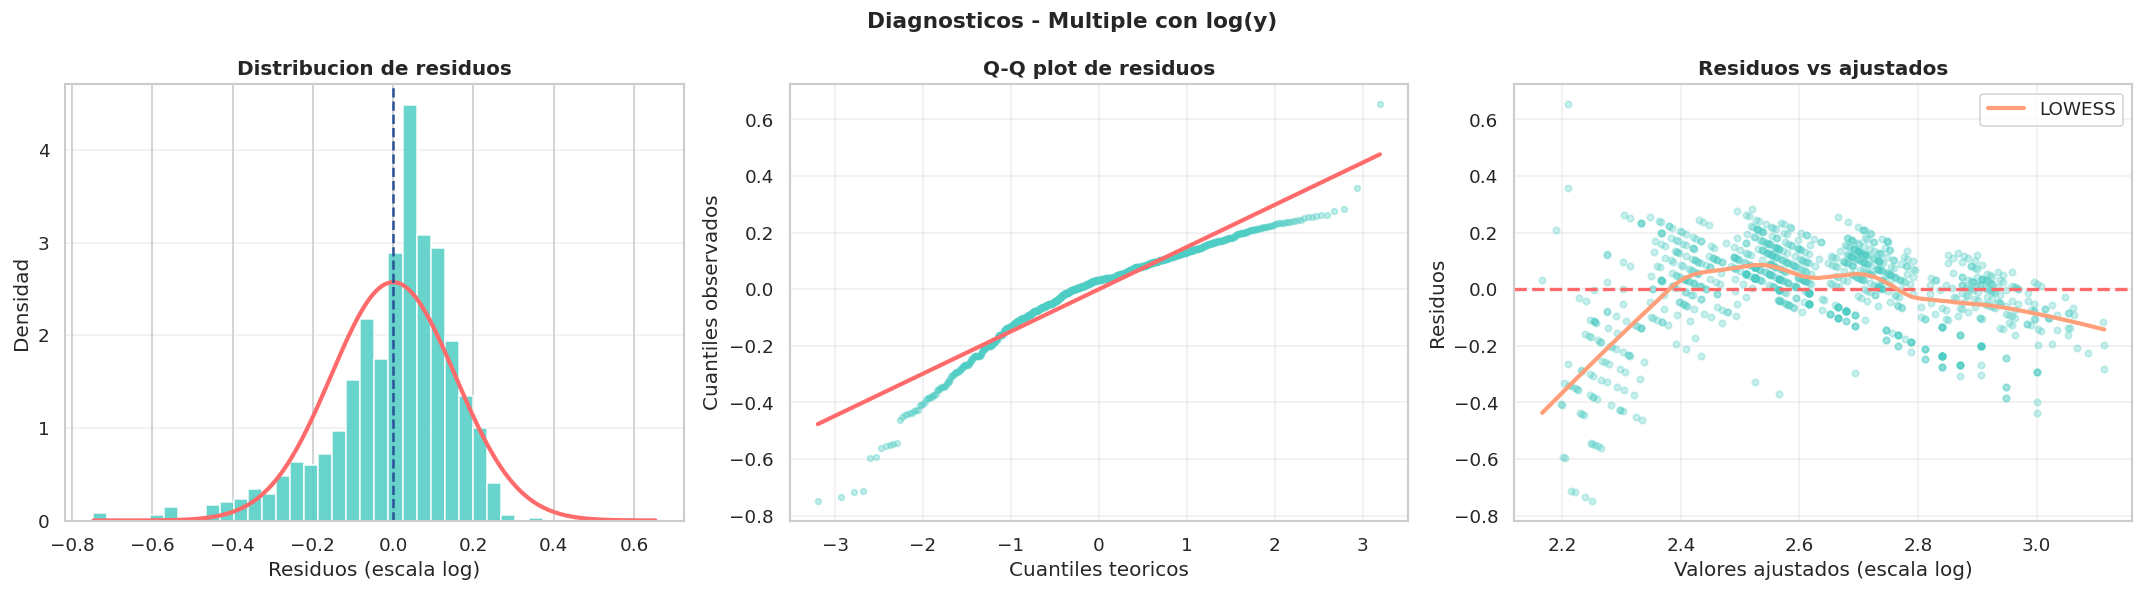


Test Shapiro-Wilk (normalidad) - log(y):
p-value: 0.000000
Conclusion: Se rechaza normalidad

Test Breusch-Pagan (homocedasticidad) - log(y):
p-value: 0.000000
Conclusion: Heterocedasticidad detectada


In [38]:
# CELDA 21.1 - Multiple con log(y)
# 🎯 Objetivo: reducir heterocedasticidad transformando y = log(vida_promedio)

# Validacion: log requiere y > 0
if (y_train_m <= 0).any() or (y_test_m <= 0).any():
    raise ValueError('No se puede aplicar log(y) porque hay valores de vida_promedio <= 0')

y_train_log = np.log(y_train_m)
y_test_log = np.log(y_test_m)

modelo_multi_log = LinearRegression()
modelo_multi_log.fit(X_train_m, y_train_log)

y_pred_log = modelo_multi_log.predict(X_test_m)
y_pred_log_orig = np.exp(y_pred_log)

# Metricas en escala original
r2_m_log_orig = r2_score(y_test_m, y_pred_log_orig)
mse_m_log_orig = mean_squared_error(y_test_m, y_pred_log_orig)
rmse_m_log_orig = np.sqrt(mse_m_log_orig)
mae_m_log_orig = mean_absolute_error(y_test_m, y_pred_log_orig)

print('=' * 70)
print('📈 METRICAS - MULTIPLE con log(y) (evaluadas en escala original)')
print('=' * 70)
print(f'Features: {FEATURES}')
print(f'🎯 R2   : {r2_m_log_orig:.4f}')
print(f'📏 RMSE : {rmse_m_log_orig:.4f}')
print(f'🧮 MAE  : {mae_m_log_orig:.4f}')
print('=' * 70)

# OLS para diagnosticos en todo el dataset
X_ols_m = sm.add_constant(df[FEATURES])
modelo_ols_multi_log = sm.OLS(np.log(df['vida_promedio']), X_ols_m).fit()

residuos_log = modelo_ols_multi_log.resid.values
ajustados_log = modelo_ols_multi_log.fittedvalues.values

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Diagnosticos - Multiple con log(y)', fontsize=13, fontweight='bold')

axes[0].hist(residuos_log, bins=40, color='#4ecdc4', edgecolor='white', density=True, alpha=0.85)
xr = np.linspace(residuos_log.min(), residuos_log.max(), 200)
axes[0].plot(xr, stats.norm.pdf(xr, residuos_log.mean(), residuos_log.std()), color='#ff6b6b', linewidth=2.5)
axes[0].axvline(0, color='#2a5298', linestyle='--')
axes[0].set_title('Distribucion de residuos', fontweight='bold')
axes[0].set_xlabel('Residuos (escala log)')
axes[0].set_ylabel('Densidad')
axes[0].grid(axis='y', alpha=0.3)

(osm, osr), (s, i, _) = stats.probplot(residuos_log, dist='norm')
axes[1].scatter(osm, osr, alpha=0.35, s=12, color='#4ecdc4')
axes[1].plot(osm, s * np.array(osm) + i, color='#ff6b6b', linewidth=2.5)
axes[1].set_title('Q-Q plot de residuos', fontweight='bold')
axes[1].set_xlabel('Cuantiles teoricos')
axes[1].set_ylabel('Cuantiles observados')
axes[1].grid(alpha=0.3)

axes[2].scatter(ajustados_log, residuos_log, alpha=0.30, s=15, color='#4ecdc4')
axes[2].axhline(0, color='#ff6b6b', linestyle='--', linewidth=2)
lowess_log = sm.nonparametric.lowess(residuos_log, ajustados_log, frac=0.3)
axes[2].plot(lowess_log[:, 0], lowess_log[:, 1], color='#ffa07a', linewidth=2.5, label='LOWESS')
axes[2].set_title('Residuos vs ajustados', fontweight='bold')
axes[2].set_xlabel('Valores ajustados (escala log)')
axes[2].set_ylabel('Residuos')
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../data/graficas/diagnosticos_multi_dogs_logy.png', dpi=150, bbox_inches='tight')
plt.show()

muestra_log = residuos_log if len(residuos_log) <= 5000 else np.random.default_rng(42).choice(residuos_log, 5000, replace=False)
stat_sw_log, p_sw_log = stats.shapiro(muestra_log)
lm_log, lm_p_log, _, _ = het_breuschpagan(modelo_ols_multi_log.resid, modelo_ols_multi_log.model.exog)

print()
print('Test Shapiro-Wilk (normalidad) - log(y):')
print(f'p-value: {p_sw_log:.6f}')
print('Conclusion:', 'No se rechaza normalidad' if p_sw_log > 0.05 else 'Se rechaza normalidad')

print()
print('Test Breusch-Pagan (homocedasticidad) - log(y):')
print(f'p-value: {lm_p_log:.6f}')
print('Conclusion:', 'Homocedasticidad OK' if lm_p_log > 0.05 else 'Heterocedasticidad detectada')


📈 METRICAS - MULTIPLE con sqrt(y) (evaluadas en escala original)
Features: ['log_peso_promedio', 'log_diferencia_sexual_peso']
🎯 R2   : 0.6987
📏 RMSE : 1.6392
🧮 MAE  : 1.3062


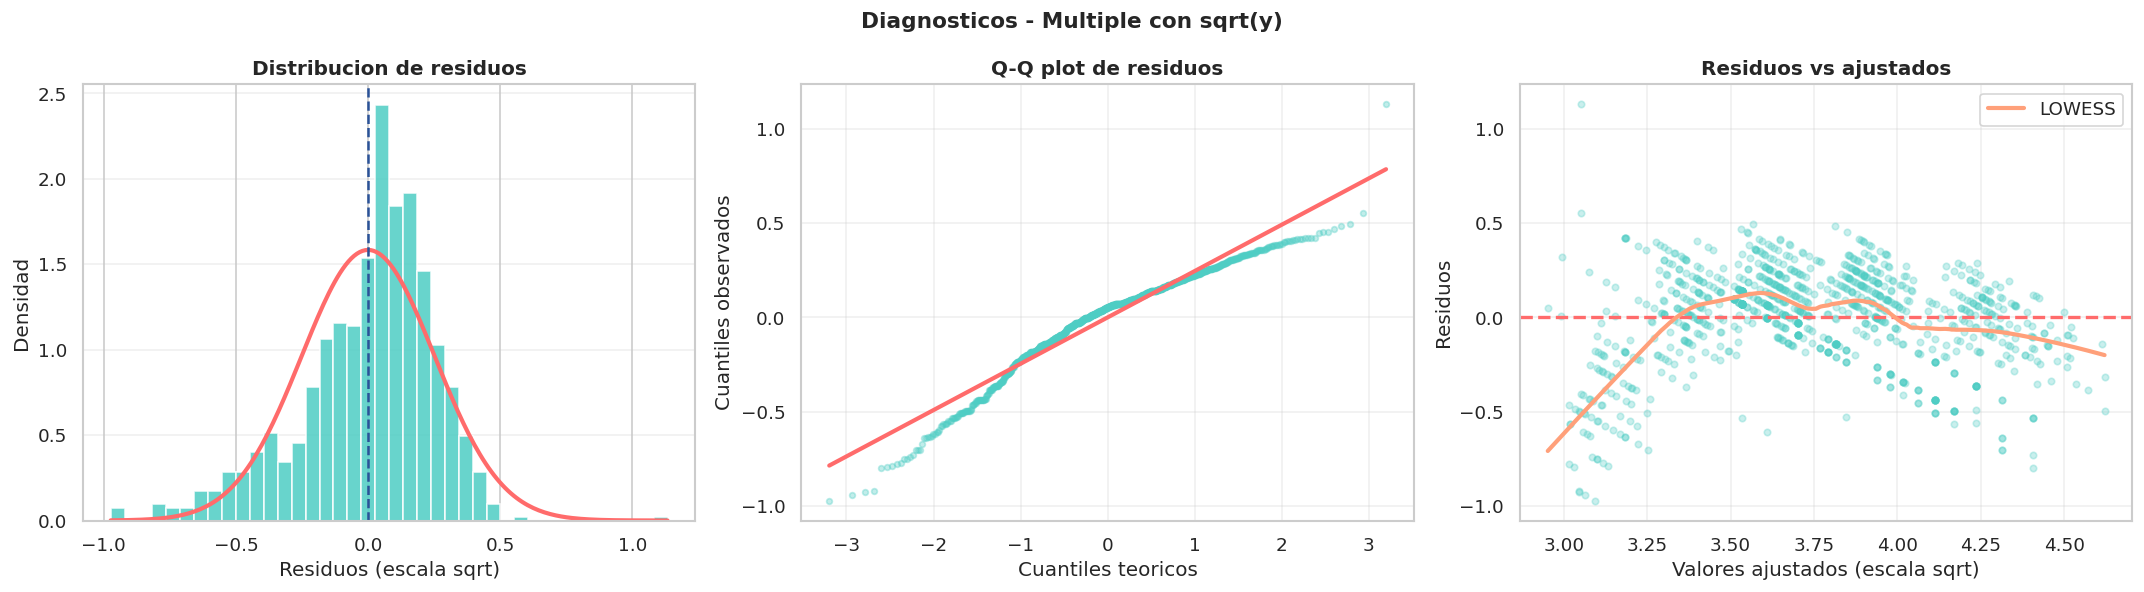


Test Shapiro-Wilk (normalidad) - sqrt(y):
p-value: 0.000000
Conclusion: Se rechaza normalidad

Test Breusch-Pagan (homocedasticidad) - sqrt(y):
p-value: 0.000000
Conclusion: Heterocedasticidad detectada


In [39]:
# CELDA 21.2 - Multiple con sqrt(y)
# 🎯 Objetivo: reducir heterocedasticidad transformando y = sqrt(vida_promedio)

# Validacion: sqrt requiere y >= 0
if (y_train_m < 0).any() or (y_test_m < 0).any():
    raise ValueError('No se puede aplicar sqrt(y) porque hay valores de vida_promedio < 0')

y_train_sqrt = np.sqrt(y_train_m)
y_test_sqrt = np.sqrt(y_test_m)

modelo_multi_sqrt = LinearRegression()
modelo_multi_sqrt.fit(X_train_m, y_train_sqrt)

y_pred_sqrt = modelo_multi_sqrt.predict(X_test_m)
y_pred_sqrt_orig = np.square(y_pred_sqrt)

# Metricas en escala original
r2_m_sqrt_orig = r2_score(y_test_m, y_pred_sqrt_orig)
mse_m_sqrt_orig = mean_squared_error(y_test_m, y_pred_sqrt_orig)
rmse_m_sqrt_orig = np.sqrt(mse_m_sqrt_orig)
mae_m_sqrt_orig = mean_absolute_error(y_test_m, y_pred_sqrt_orig)

print('=' * 72)
print('📈 METRICAS - MULTIPLE con sqrt(y) (evaluadas en escala original)')
print('=' * 72)
print(f'Features: {FEATURES}')
print(f'🎯 R2   : {r2_m_sqrt_orig:.4f}')
print(f'📏 RMSE : {rmse_m_sqrt_orig:.4f}')
print(f'🧮 MAE  : {mae_m_sqrt_orig:.4f}')
print('=' * 72)

# OLS para diagnosticos en todo el dataset
X_ols_m = sm.add_constant(df[FEATURES])
modelo_ols_multi_sqrt = sm.OLS(np.sqrt(df['vida_promedio']), X_ols_m).fit()

residuos_sqrt = modelo_ols_multi_sqrt.resid.values
ajustados_sqrt = modelo_ols_multi_sqrt.fittedvalues.values

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Diagnosticos - Multiple con sqrt(y)', fontsize=13, fontweight='bold')

axes[0].hist(residuos_sqrt, bins=40, color='#4ecdc4', edgecolor='white', density=True, alpha=0.85)
xr = np.linspace(residuos_sqrt.min(), residuos_sqrt.max(), 200)
axes[0].plot(xr, stats.norm.pdf(xr, residuos_sqrt.mean(), residuos_sqrt.std()), color='#ff6b6b', linewidth=2.5)
axes[0].axvline(0, color='#2a5298', linestyle='--')
axes[0].set_title('Distribucion de residuos', fontweight='bold')
axes[0].set_xlabel('Residuos (escala sqrt)')
axes[0].set_ylabel('Densidad')
axes[0].grid(axis='y', alpha=0.3)

(osm, osr), (s, i, _) = stats.probplot(residuos_sqrt, dist='norm')
axes[1].scatter(osm, osr, alpha=0.35, s=12, color='#4ecdc4')
axes[1].plot(osm, s * np.array(osm) + i, color='#ff6b6b', linewidth=2.5)
axes[1].set_title('Q-Q plot de residuos', fontweight='bold')
axes[1].set_xlabel('Cuantiles teoricos')
axes[1].set_ylabel('Cuantiles observados')
axes[1].grid(alpha=0.3)

axes[2].scatter(ajustados_sqrt, residuos_sqrt, alpha=0.30, s=15, color='#4ecdc4')
axes[2].axhline(0, color='#ff6b6b', linestyle='--', linewidth=2)
lowess_sqrt = sm.nonparametric.lowess(residuos_sqrt, ajustados_sqrt, frac=0.3)
axes[2].plot(lowess_sqrt[:, 0], lowess_sqrt[:, 1], color='#ffa07a', linewidth=2.5, label='LOWESS')
axes[2].set_title('Residuos vs ajustados', fontweight='bold')
axes[2].set_xlabel('Valores ajustados (escala sqrt)')
axes[2].set_ylabel('Residuos')
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../data/graficas/diagnosticos_multi_dogs_sqrty.png', dpi=150, bbox_inches='tight')
plt.show()

muestra_sqrt = residuos_sqrt if len(residuos_sqrt) <= 5000 else np.random.default_rng(42).choice(residuos_sqrt, 5000, replace=False)
stat_sw_sqrt, p_sw_sqrt = stats.shapiro(muestra_sqrt)
lm_sqrt, lm_p_sqrt, _, _ = het_breuschpagan(modelo_ols_multi_sqrt.resid, modelo_ols_multi_sqrt.model.exog)

print()
print('Test Shapiro-Wilk (normalidad) - sqrt(y):')
print(f'p-value: {p_sw_sqrt:.6f}')
print('Conclusion:', 'No se rechaza normalidad' if p_sw_sqrt > 0.05 else 'Se rechaza normalidad')

print()
print('Test Breusch-Pagan (homocedasticidad) - sqrt(y):')
print(f'p-value: {lm_p_sqrt:.6f}')
print('Conclusion:', 'Homocedasticidad OK' if lm_p_sqrt > 0.05 else 'Heterocedasticidad detectada')


🧪 COMPARACION - Original vs log(y) vs sqrt(y)
  Modelo  R2 (orig escala)  RMSE (orig escala)  MAE (orig escala)  BP p-value  Shapiro p-value
Original            0.7252              1.5656             1.2385    0.000421              0.0
 sqrt(y)            0.6987              1.6392             1.3062    0.000000              0.0
  log(y)            0.6485              1.7704             1.4210    0.000000              0.0

📌 Mejor para heterocedasticidad: mayor BP p-value (ideal > 0.05).
📌 Mejor para prediccion: menor RMSE/MAE en escala original.


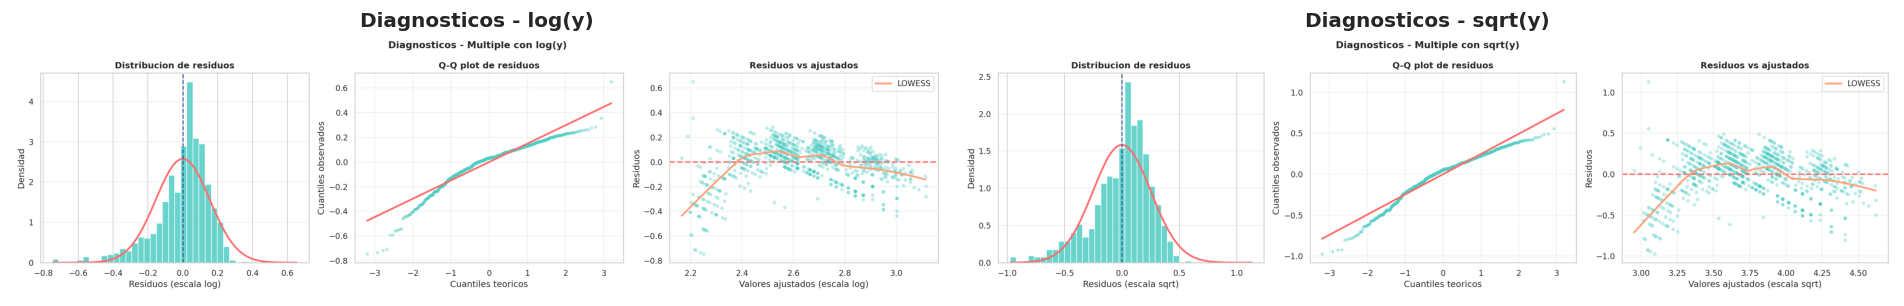

In [40]:
# CELDA 21.3 - Comparacion: Original vs log(y) vs sqrt(y)
# 🎯 Objetivo: comparar metricas y diagnosticos para elegir mejor correccion de heterocedasticidad

# Nota: 'Original' usa r2_m/rmse_m/mae_m y p-values calculados en CELDA 21 (p_sw_m, lm_p_m).
comparacion_y = pd.DataFrame({
    'Modelo': ['Original', 'log(y)', 'sqrt(y)'],
    'R2 (orig escala)': [round(r2_m, 4), round(r2_m_log_orig, 4), round(r2_m_sqrt_orig, 4)],
    'RMSE (orig escala)': [round(rmse_m, 4), round(rmse_m_log_orig, 4), round(rmse_m_sqrt_orig, 4)],
    'MAE (orig escala)': [round(mae_m, 4), round(mae_m_log_orig, 4), round(mae_m_sqrt_orig, 4)],
    'BP p-value': [round(lm_p_m, 6), round(lm_p_log, 6), round(lm_p_sqrt, 6)],
    'Shapiro p-value': [round(p_sw_m, 6), round(p_sw_log, 6), round(p_sw_sqrt, 6)],
})

comparacion_y = comparacion_y.sort_values('RMSE (orig escala)')
print('🧪 COMPARACION - Original vs log(y) vs sqrt(y)')
print('=' * 92)
print(comparacion_y.to_string(index=False))
print('=' * 92)

print()
print('📌 Mejor para heterocedasticidad: mayor BP p-value (ideal > 0.05).')
print('📌 Mejor para prediccion: menor RMSE/MAE en escala original.')

# (Opcional) Mostrar las imagenes guardadas lado a lado
try:
    import matplotlib.image as mpimg
    img1 = mpimg.imread('../data/graficas/diagnosticos_multi_dogs_logy.png')
    img2 = mpimg.imread('../data/graficas/diagnosticos_multi_dogs_sqrty.png')
    fig, ax = plt.subplots(1, 2, figsize=(16, 6))
    ax[0].imshow(img1)
    ax[0].axis('off')
    ax[0].set_title('Diagnosticos - log(y)', fontweight='bold')
    ax[1].imshow(img2)
    ax[1].axis('off')
    ax[1].set_title('Diagnosticos - sqrt(y)', fontweight='bold')
    plt.tight_layout()
    plt.show()
except Exception as e:
    print('No se pudieron cargar las imagenes (opcional):', e)


In [41]:
# CELDA 22 - Comparacion final de modelos
# 🎯 Objetivo: comparar modelo simple vs multiple con metricas clave
comparacion = pd.DataFrame({
    'Modelo': ['Regresion Simple', 'Regresion Multiple'],
    'Variables': [
        'log_peso_promedio',
        'log_peso_promedio + log_diferencia_sexual_peso'
    ],
    'R2': [round(r2, 4), round(r2_m, 4)],
    'R2 Aj.': [round(modelo_ols_simple.rsquared_adj, 4), round(modelo_ols_multi.rsquared_adj, 4)],
    'RMSE': [round(rmse, 4), round(rmse_m, 4)],
    'MAE': [round(mae, 4), round(mae_m, 4)],
    'AIC': [round(modelo_ols_simple.aic, 2), round(modelo_ols_multi.aic, 2)],
    'BIC': [round(modelo_ols_simple.bic, 2), round(modelo_ols_multi.bic, 2)],
})

print('📊 COMPARACION DE MODELOS - DATA-DOGS')
print('=' * 94)
print(comparacion.to_string(index=False))
print('=' * 94)
print()
print('📌 AIC/BIC más bajo -> mejor equilibrio entre ajuste y parsimonia.')


📊 COMPARACION DE MODELOS - DATA-DOGS
            Modelo                                      Variables     R2  R2 Aj.   RMSE    MAE     AIC     BIC
  Regresion Simple                              log_peso_promedio 0.7252  0.6987 1.5653 1.2385 3920.90 3930.72
Regresion Multiple log_peso_promedio + log_diferencia_sexual_peso 0.7252  0.6984 1.5656 1.2385 3922.88 3937.61

📌 AIC/BIC más bajo -> mejor equilibrio entre ajuste y parsimonia.


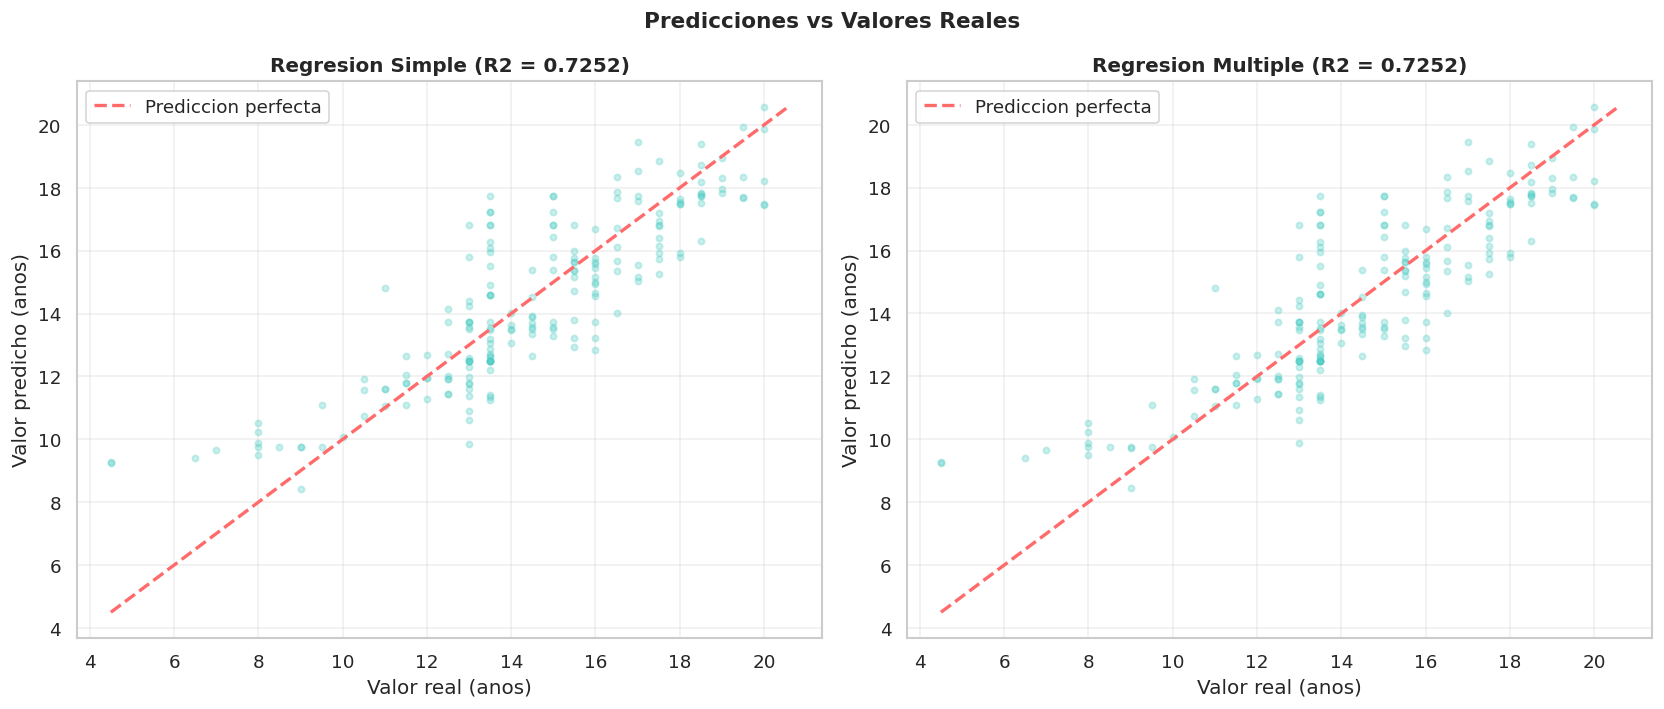

In [36]:
# CELDA 23 - Predicciones vs valores reales
# 🎯 Objetivo: comparar predicciones vs valores reales en ambos modelos
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Predicciones vs Valores Reales', fontsize=13, fontweight='bold')

for ax, (y_real, y_pred, titulo) in zip(axes, [
    (y_test, y_pred_simple, 'Regresion Simple'),
    (y_test_m, y_pred_multi, 'Regresion Multiple'),
]):
    minval = min(y_real.min(), y_pred.min())
    maxval = max(y_real.max(), y_pred.max())
    ax.scatter(y_real, y_pred, alpha=0.30, s=14, color='#4ecdc4')
    ax.plot([minval, maxval], [minval, maxval], color='#ff6b6b', linewidth=2, linestyle='--', label='Prediccion perfecta')
    r2_val = r2_score(y_real, y_pred)
    ax.set_title(f'{titulo} (R2 = {r2_val:.4f})', fontweight='bold')
    ax.set_xlabel('Valor real (anos)')
    ax.set_ylabel('Valor predicho (anos)')
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../data/graficas/predicciones_vs_reales_dogs.png', dpi=150, bbox_inches='tight')
plt.show()
